# Credit Risk Model — Default Prediction with Explainability, Calibration & Fairness

**Dataset:** Lending Club accepted loans, 2015–2018 vintages.

**Pipeline:** EDA → Feature Engineering → Time-Based Split → Modeling → Calibration → Explainability (SHAP) → Fairness → Conclusion

---

### How to run this notebook

This notebook is **runnable as-is**. It looks for a real Lending Club CSV and, if it does not
find one, generates a schema-compatible synthetic dataset so that every cell below still executes.
All downstream code is identical for both paths.

**To use the real data**, download `accepted_2007_to_2018Q4.csv.gz` from Kaggle
(*"Lending Club Loan Data" / wordsforthewise/lending-club*) and either:

- place it next to this notebook, or
- set the path in the config cell below (`LC_CSV_PATH`), or
- export `LC_CSV_PATH=/path/to/accepted_2007_to_2018Q4.csv.gz` before launching Jupyter.

**Dependencies:** `numpy pandas scikit-learn matplotlib` are required.
`lightgbm` / `xgboost` / `shap` are optional — the notebook degrades gracefully
(scikit-learn's `HistGradientBoostingClassifier` and XGBoost's built-in TreeSHAP
are used as fallbacks) but installing them is recommended:

```
pip install lightgbm xgboost shap
```

## 0. Setup and configuration

In [1]:
# ============================================================================
# Imports and global configuration
# ============================================================================
import os
import sys
import warnings
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.isotonic import IsotonicRegression
from sklearn.calibration import calibration_curve
from sklearn.metrics import (
    roc_auc_score, average_precision_score, roc_curve, precision_recall_curve,
    confusion_matrix, brier_score_loss, f1_score, log_loss,
)

from IPython.display import Markdown, display

warnings.filterwarnings("ignore")
%matplotlib inline

# Plot styling ---------------------------------------------------------------
plt.rcParams.update({
    "figure.figsize": (9, 5),
    "figure.dpi": 110,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 10,
})

# Reproducibility ------------------------------------------------------------
RANDOM_SEED = 42
rng = np.random.default_rng(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

# ============================================================================
# CONFIG — edit these
# ============================================================================
# Path to the real Lending Club CSV. If the file does not exist, synthetic data
# with an identical schema is generated instead so the notebook stays runnable.
LC_CSV_PATH = os.environ.get("LC_CSV_PATH", "accepted_2007_to_2018Q4.csv.gz")

N_SYNTHETIC     = 120_000   # rows to generate if the real CSV is unavailable
VINTAGE_MIN     = 2015      # keep loans issued in [VINTAGE_MIN, VINTAGE_MAX]
VINTAGE_MAX     = 2018
TRAIN_YEARS     = [2015, 2016]   # model fitting
VALID_YEARS     = [2017]         # early stopping + threshold + calibration fitting
TEST_YEARS      = [2018]         # held-out, strictly later than everything above

# Include Lending Club's own risk assessment (grade / sub_grade / int_rate) as
# features?  These ARE available at origination, so using them is not leakage —
# but they are the output of LC's internal model. Set to False to build a true
# "challenger" model that scores applicants from raw bureau data alone.
USE_LC_GRADE = True

TARGET_APPROVAL_RATE = 0.85  # used for the business-threshold variant

# ============================================================================
# Optional dependencies — everything below has a fallback
# ============================================================================
try:
    import lightgbm as lgb
    HAS_LGB = True
except ImportError:
    HAS_LGB = False

try:
    import xgboost as xgb
    HAS_XGB = True
except ImportError:
    HAS_XGB = False

try:
    import shap
    HAS_SHAP = True
except ImportError:
    HAS_SHAP = False

print(f"python      {sys.version.split()[0]}")
print(f"numpy       {np.__version__}")
print(f"pandas      {pd.__version__}")
import sklearn; print(f"scikit-learn {sklearn.__version__}")
print(f"lightgbm    {lgb.__version__ if HAS_LGB else 'not installed (fallback active)'}")
print(f"xgboost     {xgb.__version__ if HAS_XGB else 'not installed (fallback active)'}")
print(f"shap        {shap.__version__ if HAS_SHAP else 'not installed (fallback active)'}")

python      3.12.3
numpy       2.4.4
pandas      3.0.2
scikit-learn 1.8.0
lightgbm    4.7.0
xgboost     3.4.0
shap        0.52.0


## 1. Data loading

### 1.1 Leakage control — the single most important step

Lending Club's dump mixes **origination-time** fields with **post-origination outcome** fields in
the same table. Columns such as `total_pymnt`, `recoveries`, `last_pymnt_amnt` and
`last_fico_range_high` are recorded *after* the loan performs, so they encode the label almost
perfectly. Models trained on them report AUCs above 0.99 and are worthless in deployment, because
none of those values exist when you are deciding whether to fund an application.

The block below defines an explicit allow-list of application-time features and a deny-list of
leaky columns. Anything not on the allow-list never reaches the model.

In [2]:
# ============================================================================
# Column contracts
# ============================================================================

# --- Features known at the moment of application / origination --------------
APPLICATION_COLS = [
    # loan terms (known when the offer is priced)
    "loan_amnt", "term", "int_rate", "installment", "grade", "sub_grade",
    "initial_list_status", "application_type",
    # borrower-stated
    "emp_length", "home_ownership", "annual_inc", "verification_status",
    "purpose", "addr_state", "dti",
    # credit bureau pull at application time
    "delinq_2yrs", "earliest_cr_line", "fico_range_low", "fico_range_high",
    "inq_last_6mths", "mths_since_last_delinq", "open_acc", "pub_rec",
    "revol_bal", "revol_util", "total_acc", "mort_acc", "pub_rec_bankruptcies",
]

META_COLS = ["issue_d", "loan_status"]   # needed for target + time split, not features

# --- Post-origination outcome fields: NEVER use as features -----------------
LEAKY_COLS = [
    "out_prncp", "out_prncp_inv", "total_pymnt", "total_pymnt_inv",
    "total_rec_prncp", "total_rec_int", "total_rec_late_fee", "recoveries",
    "collection_recovery_fee", "last_pymnt_d", "last_pymnt_amnt",
    "next_pymnt_d", "last_credit_pull_d", "last_fico_range_high",
    "last_fico_range_low", "debt_settlement_flag", "settlement_status",
    "settlement_amount", "hardship_flag", "hardship_status",
    "funded_amnt", "funded_amnt_inv", "pymnt_plan", "policy_code",
]

# --- Target definition ------------------------------------------------------
BAD_STATUS = {
    "Charged Off",
    "Default",
    "Does not meet the credit policy. Status:Charged Off",
}
GOOD_STATUS = {
    "Fully Paid",
    "Does not meet the credit policy. Status:Fully Paid",
}
# Everything else ("Current", "Late (31-120 days)", "In Grace Period", ...) is an
# unresolved loan with no observed outcome yet and is dropped.

print(f"{len(APPLICATION_COLS)} application-time features, {len(LEAKY_COLS)} leaky columns blocked")

28 application-time features, 24 leaky columns blocked


### 1.2 Synthetic fallback generator

Used only when the real CSV is absent. It emits the **same column names, dtypes and quirks**
(percent-string `revol_util`, `"Dec-2015"` date strings, `" 36 months"` term strings,
realistic missingness) as the Kaggle file, so every downstream cell is exercised on the same
code path either way.

The generative process: draw bureau features → compute a latent risk score → draw the default
indicator from it → *then* derive Lending Club's `grade` from a noisy view of that same latent
score. That ordering makes `grade` informative but imperfect, which is what the real data looks
like. A mild upward drift in default rate is injected into the 2018 vintage so that the
calibration section has something real to detect.

In [3]:
def make_synthetic_lending_club(n=N_SYNTHETIC, seed=RANDOM_SEED):
    """Generate a Lending-Club-shaped dataset with realistic dependence structure.

    Returns a DataFrame with the same column names/dtypes as the Kaggle dump,
    including the messy string formats that the parsers below have to handle.
    """
    r = np.random.default_rng(seed)

    # ---- issuance dates, weighted toward later vintages (LC grew over time) --
    years  = r.choice([2015, 2016, 2017, 2018], size=n, p=[0.22, 0.24, 0.26, 0.28])
    months = r.integers(1, 13, size=n)
    month_abbr = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]
    issue_d = [f"{month_abbr[m-1]}-{y}" for m, y in zip(months, years)]

    # ---- borrower / bureau attributes ---------------------------------------
    fico          = np.clip(r.normal(698, 31, n), 660, 850).round(0)
    annual_inc    = np.clip(np.exp(r.normal(11.05, 0.55, n)), 8_000, 800_000).round(0)
    dti           = np.clip(r.gamma(6.0, 3.1, n), 0, 60).round(2)
    revol_util    = np.clip(r.normal(52, 24, n), 0, 140).round(1)
    revol_bal     = np.clip(r.gamma(2.0, 8_500, n), 0, 500_000).round(0)
    total_acc     = np.clip(r.poisson(24, n), 2, 120)
    open_acc      = np.clip((total_acc * r.uniform(0.25, 0.7, n)).round(), 1, None)
    delinq_2yrs   = r.poisson(0.30, n)
    inq_last_6mths= r.poisson(0.62, n)
    pub_rec       = r.poisson(0.18, n)
    pub_rec_bk    = np.minimum(pub_rec, r.poisson(0.12, n))
    mort_acc      = r.poisson(1.6, n)
    cr_hist_years = np.clip(r.gamma(5.0, 3.2, n), 1.5, 55)

    term_months   = r.choice([36, 60], size=n, p=[0.72, 0.28])
    loan_amnt     = (np.clip(r.gamma(3.0, 5_200, n), 1_000, 40_000) / 25).round() * 25

    purpose = r.choice(
        ["debt_consolidation", "credit_card", "home_improvement", "other",
         "major_purchase", "medical", "small_business", "car", "moving",
         "vacation", "house", "renewable_energy"],
        size=n, p=[0.57, 0.22, 0.06, 0.055, 0.02, 0.015, 0.013, 0.012,
                   0.010, 0.009, 0.010, 0.006])
    home_ownership = r.choice(["MORTGAGE", "RENT", "OWN", "ANY"], size=n,
                              p=[0.49, 0.39, 0.115, 0.005])
    verification_status = r.choice(["Source Verified", "Verified", "Not Verified"],
                                   size=n, p=[0.40, 0.31, 0.29])
    emp_length_num = np.clip(r.geometric(0.16, n) - 1, 0, 10)
    emp_length = np.where(
        r.random(n) < 0.06, None,
        np.where(emp_length_num == 0, "< 1 year",
        np.where(emp_length_num == 10, "10+ years",
                 np.char.add(emp_length_num.astype(str), " years"))))

    states = ["CA","TX","NY","FL","IL","NJ","PA","OH","GA","VA","NC","MI","MD",
              "AZ","MA","WA","CO","MN","IN","MO","TN","CT","NV","WI","AL","SC",
              "OR","LA","KY","OK","KS","AR","UT","NM","MS","NE","WV","NH","HI",
              "RI","MT","DE","AK","WY","DC","SD","VT","ID","ME","ND"]
    state_p = np.linspace(3.0, 0.4, len(states)); state_p /= state_p.sum()
    addr_state = r.choice(states, size=n, p=state_p)

    # ---- latent risk: standardised drivers + unobserved heterogeneity --------
    loan_to_inc = loan_amnt / annual_inc
    z = (
        0.95 * (-(fico - 698) / 31)
      + 0.40 * ((dti - 18) / 9)
      + 0.30 * ((revol_util - 52) / 24)
      + 0.22 * np.minimum(delinq_2yrs, 4)
      + 0.16 * np.minimum(inq_last_6mths, 6)
      + 0.18 * np.minimum(pub_rec, 3)
      + 0.42 * (term_months == 60)
      + 0.55 * np.clip((loan_to_inc - 0.22) / 0.18, -2.0, 3.5)
      - 0.11 * ((emp_length_num - 4) / 3.3)
      - 0.13 * ((cr_hist_years - 16) / 10)
      + 0.20 * (home_ownership == "RENT")
      - 0.12 * (home_ownership == "MORTGAGE")
      + 0.45 * (purpose == "small_business")
      + 0.18 * (purpose == "medical")
      - 0.15 * (purpose == "credit_card")
      + r.normal(0, 0.80, n)                      # unobservable borrower quality
    )
    # Vintage drift: 2018 book underwritten looser -> higher realised default rate.
    z = z + np.where(years == 2018, 0.18, 0.0) + np.where(years == 2017, 0.06, 0.0)

    # Intercept tuned so the overall default rate lands near LC's real ~20%.
    p_default = 1.0 / (1.0 + np.exp(-(-2.05 + 0.78 * z)))
    default   = (r.random(n) < p_default).astype(int)

    # ---- LC's own grading: a noisy read of the same latent score ------------
    z_graded = z + r.normal(0, 0.62, n)
    pct = pd.Series(z_graded).rank(pct=True).to_numpy()
    grade_edges  = [0.0, 0.17, 0.45, 0.71, 0.87, 0.955, 0.99, 1.0001]
    grade_letters = ["A", "B", "C", "D", "E", "F", "G"]
    gi = np.clip(np.digitize(pct, grade_edges[1:-1], right=False), 0, 6)
    grade = np.array(grade_letters)[gi]
    sub_idx = np.clip((r.random(n) * 5).astype(int) + 1, 1, 5)
    sub_grade = np.char.add(grade, sub_idx.astype(str))

    base_rate = {"A": 6.8, "B": 10.4, "C": 14.0, "D": 18.2, "E": 22.0, "F": 26.0, "G": 29.0}
    int_rate = np.array([base_rate[g] for g in grade]) + r.normal(0, 0.85, n)
    int_rate = np.clip(int_rate, 5.31, 30.99).round(2)

    # amortising payment formula, matches LC's `installment`
    mr = int_rate / 100 / 12
    installment = (loan_amnt * mr / (1 - (1 + mr) ** (-term_months))).round(2)

    # ---- earliest_cr_line as a "Mon-YYYY" string ---------------------------
    issue_ts = pd.to_datetime(pd.Series(issue_d), format="%b-%Y")
    earliest = issue_ts - pd.to_timedelta((cr_hist_years * 365.25).astype(int), unit="D")
    earliest_cr_line = earliest.dt.strftime("%b-%Y").to_numpy()

    # ---- realistic missingness ---------------------------------------------
    mths_since_last_delinq = np.where(
        delinq_2yrs > 0, r.integers(1, 24, n).astype(float),
        np.where(r.random(n) < 0.42, r.integers(24, 120, n).astype(float), np.nan))
    dti_out = dti.astype(float);              dti_out[r.random(n) < 0.004] = np.nan
    revol_util_out = revol_util.copy();       revol_util_out[r.random(n) < 0.007] = np.nan
    mort_acc_out = mort_acc.astype(float);    mort_acc_out[r.random(n) < 0.02] = np.nan

    # revol_util arrives as a percent STRING in several public dumps
    revol_util_str = np.where(np.isnan(revol_util_out), None,
                              np.char.add(np.round(revol_util_out, 1).astype(str), "%"))

    # ---- resolved status; a slice of the 2018 book is still Current ---------
    status = np.where(default == 1, "Charged Off", "Fully Paid")
    unresolved = (years == 2018) & (r.random(n) < 0.30) & (term_months == 60)
    status = np.where(unresolved, "Current", status)

    df = pd.DataFrame({
        "issue_d": issue_d, "loan_status": status,
        "loan_amnt": loan_amnt,
        "term": np.where(term_months == 36, " 36 months", " 60 months"),
        "int_rate": int_rate, "installment": installment,
        "grade": grade, "sub_grade": sub_grade,
        "initial_list_status": r.choice(["w", "f"], n, p=[0.72, 0.28]),
        "application_type": r.choice(["Individual", "Joint App"], n, p=[0.95, 0.05]),
        "emp_length": emp_length, "home_ownership": home_ownership,
        "annual_inc": annual_inc, "verification_status": verification_status,
        "purpose": purpose, "addr_state": addr_state, "dti": dti_out,
        "delinq_2yrs": delinq_2yrs, "earliest_cr_line": earliest_cr_line,
        "fico_range_low": fico, "fico_range_high": fico + 4,
        "inq_last_6mths": inq_last_6mths,
        "mths_since_last_delinq": mths_since_last_delinq,
        "open_acc": open_acc, "pub_rec": pub_rec, "revol_bal": revol_bal,
        "revol_util": revol_util_str, "total_acc": total_acc,
        "mort_acc": mort_acc_out, "pub_rec_bankruptcies": pub_rec_bk,
        # a couple of leaky columns, deliberately included so the drop logic
        # below is actually exercised rather than being a no-op
        "total_pymnt": np.where(default == 1, loan_amnt * r.uniform(0.1, 0.6, n),
                                installment * term_months).round(2),
        "recoveries": np.where(default == 1, loan_amnt * r.uniform(0, 0.15, n), 0.0).round(2),
        "last_fico_range_high": np.where(default == 1, fico - r.integers(40, 150, n),
                                         fico + r.integers(0, 40, n)),
    })
    return df

In [4]:
def load_lending_club(path=LC_CSV_PATH):
    """Load the real Lending Club CSV if present, else fall back to synthetic data.

    Returns (DataFrame, source_label). Only columns we are allowed to look at are
    read from disk, which also keeps memory manageable on the full 2.2M-row file.
    """
    if os.path.exists(path):
        wanted = META_COLS + APPLICATION_COLS
        # Read the header first so we only request columns that actually exist.
        header = pd.read_csv(path, nrows=0, low_memory=False).columns
        usecols = [c for c in wanted if c in header]
        missing = sorted(set(wanted) - set(usecols))
        if missing:
            print(f"NOTE: columns absent from this dump and skipped: {missing}")
        df = pd.read_csv(path, usecols=usecols, low_memory=False)
        return df, f"real Lending Club file: {path}"

    print(f"'{path}' not found -> generating synthetic Lending-Club-shaped data.")
    print("   Set LC_CSV_PATH (config cell) to point at the real CSV for real results.\n")
    return make_synthetic_lending_club(), f"SYNTHETIC ({N_SYNTHETIC:,} rows)"


raw, DATA_SOURCE = load_lending_club()
IS_SYNTHETIC = DATA_SOURCE.startswith("SYNTHETIC")

# Hard guarantee: no post-origination column survives, whatever the source.
dropped = [c for c in raw.columns if c in LEAKY_COLS]
raw = raw.drop(columns=dropped)
if dropped:
    print(f"Dropped {len(dropped)} leaky post-origination columns: {dropped}\n")

print(f"Source : {DATA_SOURCE}")
print(f"Shape  : {raw.shape[0]:,} rows x {raw.shape[1]} columns")
raw.head(3)

'accepted_2007_to_2018Q4.csv.gz' not found -> generating synthetic Lending-Club-shaped data.
   Set LC_CSV_PATH (config cell) to point at the real CSV for real results.



Dropped 3 leaky post-origination columns: ['total_pymnt', 'recoveries', 'last_fico_range_high']

Source : SYNTHETIC (120,000 rows)
Shape  : 120,000 rows x 30 columns


,issue_d,loan_status,loan_amnt,term,int_rate,installment,grade,sub_grade,initial_list_status,application_type,...,fico_range_high,inq_last_6mths,mths_since_last_delinq,open_acc,pub_rec,revol_bal,revol_util,total_acc,mort_acc,pub_rec_bankruptcies
0,Jun-2018,Fully Paid,18225.0,36 months,21.63,692.54,E,E2,f,Individual,...,664.0,0,32.0,10.0,0,10894.0,45.1%,17,2.0,0
1,Aug-2016,Fully Paid,20525.0,36 months,20.26,765.50,D,D1,w,Individual,...,664.0,0,NaN,19.0,0,1061.0,53.8%,27,3.0,0
2,Jun-2018,Charged Off,6625.0,36 months,11.37,218.06,B,B4,f,Individual,...,703.0,1,39.0,15.0,0,17229.0,16.4%,34,NaN,0


## 2. Exploratory Data Analysis

### 2.1 Target definition and vintage filter

In [5]:
# ---- parse issue date and restrict to the 2015-2018 vintages ---------------
df = raw.copy()
df["issue_dt"]   = pd.to_datetime(df["issue_d"], format="%b-%Y")
df["issue_year"] = df["issue_dt"].dt.year

n_before = len(df)
df = df[df["issue_year"].between(VINTAGE_MIN, VINTAGE_MAX)].copy()
print(f"Vintage filter {VINTAGE_MIN}-{VINTAGE_MAX}: {n_before:,} -> {len(df):,} rows")

# ---- define the binary target ---------------------------------------------
# 1 = bad (Charged Off / Default), 0 = good (Fully Paid).
# Unresolved loans (Current, Late, In Grace Period) have no observed outcome
# and are removed -- keeping them would silently label future defaults as good.
status_counts = df["loan_status"].value_counts()
print("\nLoan status distribution:")
print(status_counts.to_string())

df["target"] = np.where(df["loan_status"].isin(BAD_STATUS), 1,
                np.where(df["loan_status"].isin(GOOD_STATUS), 0, -1))

n_unresolved = int((df["target"] == -1).sum())
df = df[df["target"] >= 0].copy()
print(f"\nDropped {n_unresolved:,} unresolved loans -> {len(df):,} resolved loans")
print(f"Overall default rate: {df['target'].mean():.2%}  "
      f"(class imbalance ~ 1:{(1 - df['target'].mean()) / df['target'].mean():.1f})")

Vintage filter 2015-2018: 120,000 -> 120,000 rows

Loan status distribution:
loan_status
Fully Paid     93085
Charged Off    24027
Current         2888



Dropped 2,888 unresolved loans -> 117,112 resolved loans
Overall default rate: 20.52%  (class imbalance ~ 1:3.9)


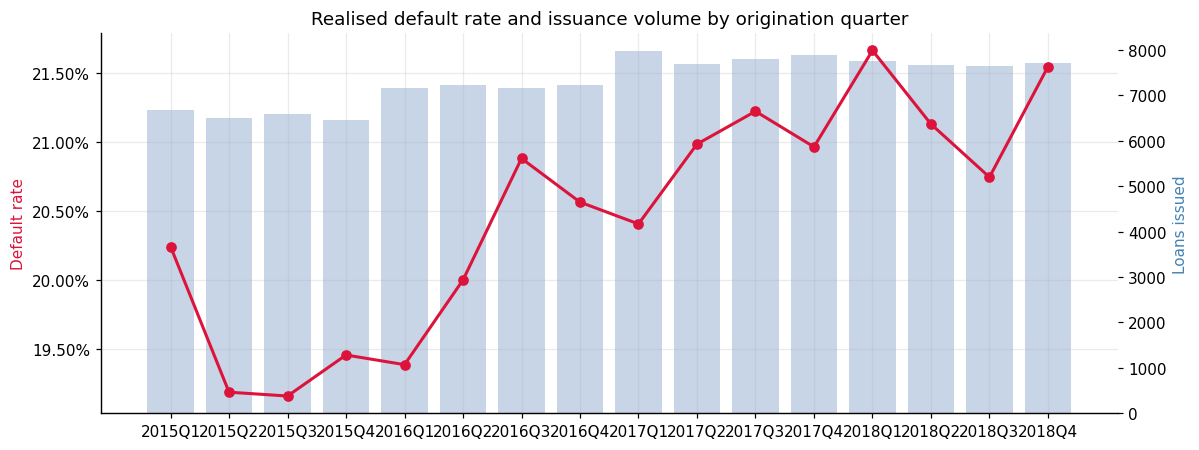

     q  default_rate    n
2017Q1      0.204066 7968
2017Q2      0.209862 7686
2017Q3      0.212245 7807
2017Q4      0.209659 7889
2018Q1      0.216662 7754
2018Q2      0.211315 7671
2018Q3      0.207461 7640
2018Q4      0.215483 7699


In [6]:
# ============================================================================
# Default rate by vintage + volume -- the basis for the time-based split
# ============================================================================
by_q = (df.assign(q=df["issue_dt"].dt.to_period("Q").astype(str))
          .groupby("q", as_index=False)
          .agg(default_rate=("target", "mean"), n=("target", "size")))

fig, ax1 = plt.subplots(figsize=(11, 4.2))
ax2 = ax1.twinx()
ax2.bar(by_q["q"], by_q["n"], color="lightsteelblue", alpha=0.7, label="loan count")
ax1.plot(by_q["q"], by_q["default_rate"], "o-", color="crimson", lw=2, label="default rate")
ax1.set_ylabel("Default rate", color="crimson")
ax1.yaxis.set_major_formatter(PercentFormatter(1.0))
ax2.set_ylabel("Loans issued", color="steelblue")
ax2.grid(False)
ax1.set_zorder(2); ax1.patch.set_visible(False)
plt.xticks(rotation=60, ha="right")
plt.title("Realised default rate and issuance volume by origination quarter")
plt.tight_layout(); plt.show()

# A drifting default rate is exactly why a random split would be misleading:
# a random split lets the model see 2018 loans while "training on the past".
print(by_q.tail(8).to_string(index=False))

Columns with missing values (fraction):
mths_since_last_delinq    0.430161
emp_length                0.059968
mort_acc                  0.019332
revol_util                0.007292
dti                       0.003714


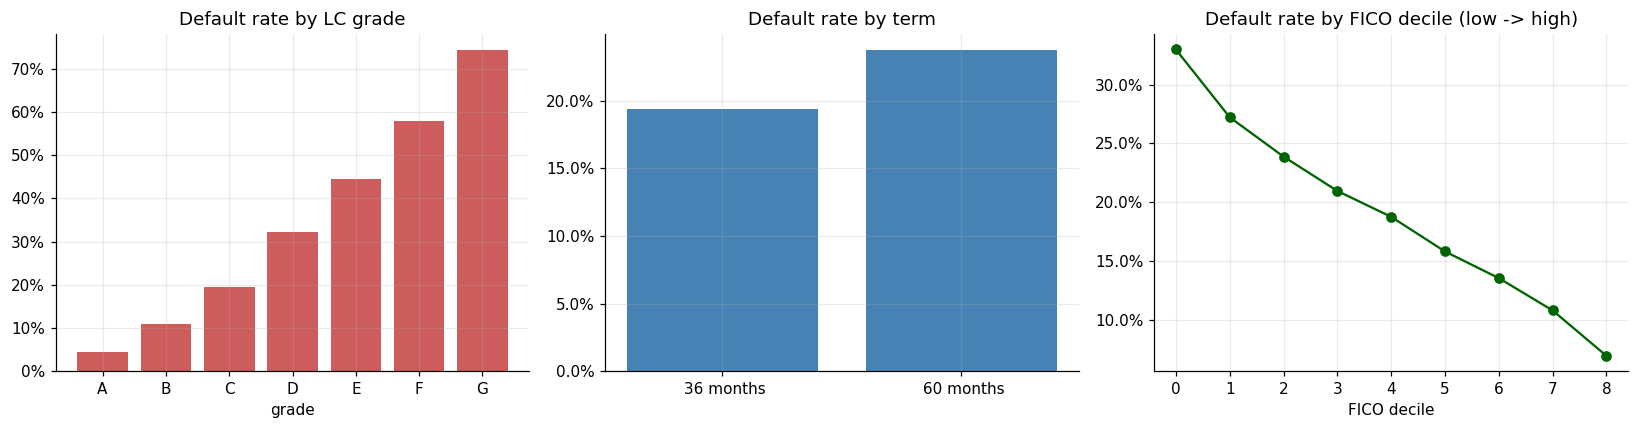

In [7]:
# ============================================================================
# Missingness and univariate risk signal
# ============================================================================
miss = (df[[c for c in APPLICATION_COLS if c in df.columns]].isna().mean()
          .sort_values(ascending=False))
miss = miss[miss > 0]
print("Columns with missing values (fraction):")
print(miss.to_string() if len(miss) else "  none")

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Default rate by LC grade -- the sanity check that the data is what we think.
g = df.groupby("grade")["target"].agg(["mean", "size"]).sort_index()
axes[0].bar(g.index, g["mean"], color="indianred")
axes[0].set_title("Default rate by LC grade"); axes[0].set_xlabel("grade")
axes[0].yaxis.set_major_formatter(PercentFormatter(1.0))

# Default rate by term
t = df.groupby("term")["target"].mean()
axes[1].bar(t.index.astype(str), t.values, color="steelblue")
axes[1].set_title("Default rate by term")
axes[1].yaxis.set_major_formatter(PercentFormatter(1.0))

# FICO vs default rate (decile bins)
fico_avg = (df["fico_range_low"] + df["fico_range_high"]) / 2
bins = pd.qcut(fico_avg, 10, duplicates="drop")
f = df.groupby(bins, observed=True)["target"].mean()
axes[2].plot(range(len(f)), f.values, "o-", color="darkgreen")
axes[2].set_title("Default rate by FICO decile (low -> high)")
axes[2].set_xlabel("FICO decile")
axes[2].yaxis.set_major_formatter(PercentFormatter(1.0))

plt.tight_layout(); plt.show()

## 3. Feature Engineering

Three groups of transformations:

1. **Parsing** — Lending Club stores several numeric fields as strings (`" 36 months"`,
   `"10+ years"`, `"34.5%"`). These are converted to numbers.
2. **Ratios** — raw levels are weak; affordability ratios are what actually carry signal.
   `loan_to_income`, `installment_to_income` (a crude payment-to-income), `revol_bal_to_income`,
   `open_acc_ratio`.
3. **Recoding** — `fico_avg` from the disclosed FICO band, `credit_history_years` as
   `issue_d − earliest_cr_line`, `sub_grade` as an ordinal 1–35 rather than 35 dummies.

**`addr_state` is deliberately excluded from the feature set.** Geography is a strong proxy for
race and ethnicity in US lending; using it as a predictor is a redlining exposure regardless of
intent. It is retained *only* as a protected-class proxy for the fairness audit in section 8.

Missing values are **not** imputed for the gradient-boosted model — LightGBM/XGBoost/HistGB learn
a default split direction for NaN, which is more informative than a median fill. Imputation is
applied only inside the logistic regression pipeline, which cannot handle NaN. Where missingness
is itself informative (`mths_since_last_delinq` is null precisely when the borrower has *no*
recorded delinquency) an explicit indicator column is added before filling.

In [8]:
def engineer_features(d):
    """Parse LC's string-encoded numerics and build ratio/recoded features.

    Returns a new DataFrame with engineered columns appended. Pure function --
    it does not read the label, so it is safe to apply before the split.
    """
    d = d.copy()

    # ---- parse string-encoded numerics -------------------------------------
    # "  36 months" -> 36
    d["term_months"] = (d["term"].astype(str)
                        .str.extract(r"(\d+)")[0].astype(float))

    # "10+ years" -> 10, "< 1 year" -> 0, "3 years" -> 3, missing -> NaN
    el = d["emp_length"].astype(str)
    d["emp_length_num"] = pd.to_numeric(el.str.extract(r"(\d+)")[0], errors="coerce")
    d.loc[el.str.contains("< 1", na=False), "emp_length_num"] = 0.0

    # "34.5%" or 34.5 -> 34.5. Public dumps differ, and pandas 1.x/2.x/3.x
    # infer different dtypes for string columns, so test for "not numeric"
    # rather than for a specific dtype.
    def strip_percent(series):
        if not pd.api.types.is_numeric_dtype(series):
            series = series.astype(str).str.strip().str.rstrip("%")
        return pd.to_numeric(series, errors="coerce")

    d["revol_util"] = strip_percent(d["revol_util"])
    d["int_rate"] = strip_percent(d["int_rate"])   # may arrive as "13.56%"

    # "C3" -> 13  (A1=1 ... G5=35), an ordinal encoding of LC's risk ladder
    sg = d["sub_grade"].astype(str)
    letter = sg.str[0].map({c: i for i, c in enumerate("ABCDEFG")})
    number = pd.to_numeric(sg.str[1], errors="coerce")
    d["sub_grade_num"] = (letter * 5 + number).astype(float)

    # ---- credit history length ---------------------------------------------
    earliest = pd.to_datetime(d["earliest_cr_line"], format="%b-%Y", errors="coerce")
    d["credit_history_years"] = (d["issue_dt"] - earliest).dt.days / 365.25
    # Guard against parse failures / nonsensical negatives
    d.loc[d["credit_history_years"] < 0, "credit_history_years"] = np.nan

    # ---- affordability ratios ----------------------------------------------
    inc = d["annual_inc"].replace(0, np.nan)          # avoid divide-by-zero
    d["log_annual_inc"]        = np.log1p(d["annual_inc"].clip(lower=0))
    d["loan_to_income"]        = d["loan_amnt"] / inc
    d["installment_to_income"] = (d["installment"] * 12) / inc
    d["revol_bal_to_income"]   = d["revol_bal"] / inc
    d["open_acc_ratio"]        = d["open_acc"] / d["total_acc"].replace(0, np.nan)

    # ---- FICO band midpoint -------------------------------------------------
    d["fico_avg"] = (d["fico_range_low"] + d["fico_range_high"]) / 2

    # ---- informative missingness -------------------------------------------
    # Null mths_since_last_delinq == "never delinquent", which is GOOD news, not
    # unknown. Flag it, then fill with a sentinel beyond the observed range.
    d["never_delinq"] = d["mths_since_last_delinq"].isna().astype(int)
    d["mths_since_last_delinq"] = d["mths_since_last_delinq"].fillna(999.0)

    # ---- clip physically impossible / extreme values ------------------------
    d["dti"] = d["dti"].clip(lower=0, upper=100)
    d["revol_util"] = d["revol_util"].clip(lower=0, upper=200)
    d["loan_to_income"] = d["loan_to_income"].clip(upper=5)
    d["installment_to_income"] = d["installment_to_income"].clip(upper=3)
    d["revol_bal_to_income"] = d["revol_bal_to_income"].clip(upper=10)

    return d


fe = engineer_features(df)
print(f"Engineered frame: {fe.shape[0]:,} rows x {fe.shape[1]} columns")
fe[["term_months", "emp_length_num", "sub_grade_num", "credit_history_years",
    "loan_to_income", "installment_to_income", "fico_avg",
    "revol_util", "never_delinq"]].describe().T.round(3)

Engineered frame: 117,112 rows x 44 columns


,count,mean,std,min,25%,50%,75%,max
term_months,117112.0,42.314,10.567,36.000,36.000,36.000,60.000,60.000
emp_length_num,110089.0,4.335,3.565,0.000,1.000,3.000,7.000,10.000
sub_grade_num,117112.0,12.234,7.046,1.000,7.000,11.000,17.000,35.000
credit_history_years,117112.0,16.047,7.139,1.498,10.834,15.001,20.085,55.001
loan_to_income,117112.0,0.286,0.252,0.003,0.122,0.216,0.368,4.769
installment_to_income,117112.0,0.110,0.106,0.001,0.043,0.079,0.139,2.086
fico_avg,117112.0,701.703,28.106,662.000,679.000,700.000,721.000,845.000
revol_util,116258.0,52.247,23.672,0.000,36.100,52.100,68.300,140.000
never_delinq,117112.0,0.430,0.495,0.000,0.000,0.000,1.000,1.000


In [9]:
# ============================================================================
# Assemble the design matrix
# ============================================================================

# Continuous / ordinal features fed to the model as-is (NaN allowed for the GBM)
NUMERIC_FEATURES = [
    "loan_amnt", "term_months", "installment", "annual_inc", "log_annual_inc",
    "dti", "delinq_2yrs", "fico_avg", "inq_last_6mths", "mths_since_last_delinq",
    "never_delinq", "open_acc", "pub_rec", "revol_bal", "revol_util", "total_acc",
    "mort_acc", "pub_rec_bankruptcies", "credit_history_years", "emp_length_num",
    "loan_to_income", "installment_to_income", "revol_bal_to_income", "open_acc_ratio",
]

# Lending Club's own risk assessment. Available at origination, so not leakage --
# but it is another model's output. Toggle USE_LC_GRADE to build a challenger
# model that must derive risk from bureau data alone.
LC_GRADE_FEATURES = ["int_rate", "sub_grade_num"]
if USE_LC_GRADE:
    NUMERIC_FEATURES = NUMERIC_FEATURES + LC_GRADE_FEATURES

# Nominal categoricals -> one-hot. All low cardinality, so this stays readable
# in the SHAP plots. NOTE: addr_state is NOT here (see the markdown above).
CATEGORICAL_FEATURES = [
    "purpose", "home_ownership", "verification_status",
    "initial_list_status", "application_type",
]
CATEGORICAL_FEATURES = [c for c in CATEGORICAL_FEATURES if c in fe.columns]

# Protected-class proxies: used ONLY for the fairness audit, never as features.
SENSITIVE_COLS = ["addr_state", "annual_inc"]

missing_feats = [c for c in NUMERIC_FEATURES if c not in fe.columns]
assert not missing_feats, f"missing engineered columns: {missing_feats}"

# One-hot encode with pandas so that column names survive into SHAP unchanged.
X_cat = pd.get_dummies(fe[CATEGORICAL_FEATURES].astype(str),
                       prefix=CATEGORICAL_FEATURES, dummy_na=False, dtype=float)
X_all = pd.concat([fe[NUMERIC_FEATURES].astype(float), X_cat], axis=1)
y_all = fe["target"].astype(int).to_numpy()

FEATURE_NAMES = list(X_all.columns)

# Final leakage assertion: nothing from the deny-list can be in the matrix.
assert not (set(FEATURE_NAMES) & set(LEAKY_COLS)), "leaky column reached the design matrix"
assert "addr_state" not in FEATURE_NAMES, "geography must not be a model feature"

print(f"Design matrix: {X_all.shape[0]:,} rows x {X_all.shape[1]} features")
print(f"  {len(NUMERIC_FEATURES)} numeric/ordinal + {X_cat.shape[1]} one-hot dummies")
print(f"  LC grade features {'INCLUDED' if USE_LC_GRADE else 'EXCLUDED (challenger mode)'}")

Design matrix: 117,112 rows x 49 features
  26 numeric/ordinal + 23 one-hot dummies
  LC grade features INCLUDED


## 4. Time-based split

A random split leaks the future into the past. Credit portfolios drift: underwriting standards
change, macro conditions change, and the borrower mix changes. A randomly-split model is
evaluated on loans issued *contemporaneously* with its training data and will overstate
out-of-time performance.

The split here mirrors deployment:

| Fold | Vintages | Role |
|---|---|---|
| Train | 2015–2016 | fit model parameters |
| Validation | 2017 | early stopping, threshold selection, **calibration fitting** |
| Test | 2018 | untouched until the final evaluation |

The validation fold has to sit strictly between train and test, because the isotonic calibrator
in section 6 is itself a fitted model. Fitting it on the test fold would be leakage.

> **Caveat on the 2018 test fold.** A 60-month loan issued in 2018 cannot have reached maturity
> by the data cut. The resolved 2018 loans are therefore biased toward *early* resolutions —
> disproportionately charge-offs — which inflates the observed default rate on the test fold.
> This is survivorship bias in the label, not a modelling bug, and it is the reason the calibration
> section matters. In production you would either restrict to matured cohorts or model
> time-to-default with survival methods.

In [10]:
# ============================================================================
# Split by origination year -- no shuffling, no random state
# ============================================================================
year = fe["issue_year"].to_numpy()
train_mask = np.isin(year, TRAIN_YEARS)
valid_mask = np.isin(year, VALID_YEARS)
test_mask  = np.isin(year, TEST_YEARS)

# Drop features that carry no information in the TRAINING fold (all-NaN, or a
# single distinct value -- e.g. a rare category that only appears post-2016).
# Doing this here rather than earlier keeps the decision out-of-time-safe, and
# keeps FEATURE_NAMES aligned with the model's coefficient/SHAP vectors.
_train_view = X_all[train_mask]
degenerate = [c for c in X_all.columns if _train_view[c].nunique(dropna=True) <= 1]
if degenerate:
    print(f"Dropping {len(degenerate)} feature(s) with no variance in train: {degenerate}")
    X_all = X_all.drop(columns=degenerate)
    FEATURE_NAMES = list(X_all.columns)

X_train, y_train = X_all[train_mask], y_all[train_mask]
X_valid, y_valid = X_all[valid_mask], y_all[valid_mask]
X_test,  y_test  = X_all[test_mask],  y_all[test_mask]

# Sensitive attributes carried alongside, aligned by the same masks.
sens_train = fe.loc[train_mask, SENSITIVE_COLS].reset_index(drop=True)
sens_test  = fe.loc[test_mask,  SENSITIVE_COLS].reset_index(drop=True)

split_summary = pd.DataFrame([
    {"fold": "train", "years": TRAIN_YEARS, "n": len(y_train), "default_rate": y_train.mean()},
    {"fold": "valid", "years": VALID_YEARS, "n": len(y_valid), "default_rate": y_valid.mean()},
    {"fold": "test",  "years": TEST_YEARS,  "n": len(y_test),  "default_rate": y_test.mean()},
])
split_summary["default_rate"] = split_summary["default_rate"].map("{:.2%}".format)
split_summary["n"] = split_summary["n"].map("{:,}".format)
display(split_summary)

assert len(y_train) > 0 and len(y_valid) > 0 and len(y_test) > 0, \
    "One fold is empty -- check TRAIN/VALID/TEST_YEARS against the data's vintage range."

# The train->test shift in base rate is the quantity calibration has to absorb.
print(f"Base-rate shift train -> test: {y_train.mean():.2%} -> {y_test.mean():.2%} "
      f"({(y_test.mean() - y_train.mean()) * 100:+.2f} pp)")

,fold,years,n,default_rate
0,train,"[2015, 2016]","54,998",19.88%
1,valid,[2017],"31,350",20.89%
2,test,[2018],"30,764",21.27%


Base-rate shift train -> test: 19.88% -> 21.27% (+1.40 pp)


## 5. Modeling

### 5.1 A note on class imbalance

Defaults are the minority class (~20%). The reflexive fix — `scale_pos_weight` /
`class_weight="balanced"` — is **not** used here, deliberately:

- It does not improve ranking. AUC and PR-AUC are invariant to monotone rescaling of the score;
  reweighting mostly relabels the same ordering.
- It **destroys calibration**. Upweighting the positive class inflates predicted probabilities
  away from the true base rate, and calibrated probabilities are a hard requirement for pricing
  (requirement 4).

Imbalance is handled where it belongs instead: **PR-AUC** as the headline discrimination metric
and an explicit **threshold choice** at decision time.

In [11]:
# ============================================================================
# 5.2 Baseline: regularised logistic regression
# ============================================================================
# Median imputation + standardisation are required (LR cannot take NaN and is
# scale-sensitive under L2). The pipeline is fit on train only -- imputation
# medians and scaling statistics never see validation or test.
logit_pipe = Pipeline([
    ("impute", SimpleImputer(strategy="median")),
    ("scale",  StandardScaler()),
    ("clf",    LogisticRegression(penalty="l2", C=1.0, max_iter=2000,
                                  solver="lbfgs", random_state=RANDOM_SEED)),
])
logit_pipe.fit(X_train, y_train)

p_valid_lr = logit_pipe.predict_proba(X_valid)[:, 1]
p_test_lr  = logit_pipe.predict_proba(X_test)[:, 1]

print(f"Logistic regression | valid AUC {roc_auc_score(y_valid, p_valid_lr):.4f} "
      f"| test AUC {roc_auc_score(y_test, p_test_lr):.4f}")

# Largest standardised coefficients -- a cheap interpretability sanity check
# before the SHAP analysis. Sign should be economically sensible.
lr_coef = logit_pipe.named_steps["clf"].coef_[0]
assert len(lr_coef) == len(FEATURE_NAMES), (
    f"coefficient/feature mismatch ({len(lr_coef)} vs {len(FEATURE_NAMES)}): "
    "a transformer dropped a column")
coefs = pd.Series(lr_coef, index=FEATURE_NAMES)
print("\nTop 12 |coefficient| (standardised units, + = raises default odds):")
print(coefs.reindex(coefs.abs().sort_values(ascending=False).index)
           .head(12).round(4).to_string())

Logistic regression | valid AUC 0.7490 | test AUC 0.7491

Top 12 |coefficient| (standardised units, + = raises default odds):
int_rate                 0.3486
fico_avg                -0.2994
sub_grade_num            0.2771
log_annual_inc          -0.2276
loan_amnt                0.1467
loan_to_income           0.1427
annual_inc               0.1137
dti                      0.1125
revol_util               0.0974
installment_to_income   -0.0610
installment             -0.0535
delinq_2yrs              0.0459


In [12]:
# ============================================================================
# 5.3 Main model: gradient-boosted trees
# ============================================================================
# Tries LightGBM -> XGBoost -> scikit-learn HistGradientBoosting so the notebook
# runs regardless of which are installed. All three handle NaN natively.

def fit_gbm(X_tr, y_tr, X_va, y_va, seed=RANDOM_SEED):
    """Fit a GBM with early stopping on the validation fold. Returns (model, name)."""
    if HAS_LGB:
        model = lgb.LGBMClassifier(
            n_estimators=2000, learning_rate=0.03, num_leaves=31,
            max_depth=-1, min_child_samples=100,
            subsample=0.8, subsample_freq=1, colsample_bytree=0.8,
            reg_alpha=0.1, reg_lambda=1.0,
            random_state=seed, n_jobs=-1, verbose=-1,
        )
        model.fit(X_tr, y_tr, eval_set=[(X_va, y_va)], eval_metric="auc",
                  callbacks=[lgb.early_stopping(100, verbose=False),
                             lgb.log_evaluation(0)])
        print(f"LightGBM stopped at {model.best_iteration_} trees")
        return model, "LightGBM"

    if HAS_XGB:
        model = xgb.XGBClassifier(
            n_estimators=2000, learning_rate=0.03, max_depth=5,
            min_child_weight=20, subsample=0.8, colsample_bytree=0.8,
            reg_alpha=0.1, reg_lambda=1.0, eval_metric="auc",
            early_stopping_rounds=100, random_state=seed,
            n_jobs=-1, tree_method="hist",
        )
        try:
            model.fit(X_tr, y_tr, eval_set=[(X_va, y_va)], verbose=False)
        except TypeError:                      # older/newer signature differences
            model.fit(X_tr, y_tr, eval_set=[(X_va, y_va)])
        print(f"XGBoost stopped at {model.best_iteration} trees")
        return model, "XGBoost"

    model = HistGradientBoostingClassifier(
        max_iter=600, learning_rate=0.05, max_leaf_nodes=31,
        min_samples_leaf=100, l2_regularization=1.0,
        early_stopping=True, validation_fraction=0.15, n_iter_no_change=50,
        random_state=seed,
    )
    model.fit(X_tr, y_tr)
    print(f"HistGradientBoosting stopped at {model.n_iter_} iterations")
    return model, "HistGradientBoosting"


gbm, GBM_NAME = fit_gbm(X_train, y_train, X_valid, y_valid)

p_valid_gbm = gbm.predict_proba(X_valid)[:, 1]
p_test_gbm  = gbm.predict_proba(X_test)[:, 1]

print(f"\n{GBM_NAME} | valid AUC {roc_auc_score(y_valid, p_valid_gbm):.4f} "
      f"| test AUC {roc_auc_score(y_test, p_test_gbm):.4f}")

LightGBM stopped at 129 trees



LightGBM | valid AUC 0.7491 | test AUC 0.7491


In [13]:
# ============================================================================
# 5.4 Metrics
# ============================================================================

def evaluate(y_true, p, threshold, label=""):
    """Discrimination + calibration metrics at a given decision threshold."""
    y_hat = (p >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_hat, labels=[0, 1]).ravel()
    base = y_true.mean()
    ap = average_precision_score(y_true, p)
    return {
        "model": label,
        "AUC-ROC": roc_auc_score(y_true, p),
        "PR-AUC": ap,
        "PR-AUC lift": ap / base,                 # vs a random classifier (= base rate)
        "Brier": brier_score_loss(y_true, p),
        "LogLoss": log_loss(y_true, p),
        "threshold": threshold,
        "precision": tp / (tp + fp) if (tp + fp) else np.nan,
        "recall(TPR)": tp / (tp + fn) if (tp + fn) else np.nan,
        "FPR": fp / (fp + tn) if (fp + tn) else np.nan,
        "F1": f1_score(y_true, y_hat, zero_division=0),
        "flagged rate": y_hat.mean(),
    }


def pick_threshold_f1(y_true, p):
    """Threshold maximising F1 on the validation fold (never on test)."""
    prec, rec, thr = precision_recall_curve(y_true, p)
    f1 = np.divide(2 * prec * rec, prec + rec,
                   out=np.zeros_like(prec), where=(prec + rec) > 0)
    return float(thr[np.argmax(f1[:-1])])


# Thresholds are chosen on VALIDATION, then applied unchanged to test.
THR_LR  = pick_threshold_f1(y_valid, p_valid_lr)
THR_GBM = pick_threshold_f1(y_valid, p_valid_gbm)

# Business alternative: approve a fixed fraction of applicants and decline the
# riskiest tail. This is closer to how a credit policy actually operates.
THR_BUSINESS = float(np.quantile(p_valid_gbm, TARGET_APPROVAL_RATE))

print(f"F1-optimal threshold  (LR)  : {THR_LR:.4f}")
print(f"F1-optimal threshold  ({GBM_NAME}) : {THR_GBM:.4f}")
print(f"Business threshold @ {TARGET_APPROVAL_RATE:.0%} approval : {THR_BUSINESS:.4f}")

results = pd.DataFrame([
    evaluate(y_test, p_test_lr,  THR_LR,       "Logistic regression"),
    evaluate(y_test, p_test_gbm, THR_GBM,      f"{GBM_NAME} (F1 threshold)"),
    evaluate(y_test, p_test_gbm, THR_BUSINESS, f"{GBM_NAME} ({TARGET_APPROVAL_RATE:.0%} approval)"),
]).set_index("model")

display(results.round(4))
print(f"\nTest-fold base rate (a random model's PR-AUC): {y_test.mean():.4f}")

F1-optimal threshold  (LR)  : 0.2267
F1-optimal threshold  (LightGBM) : 0.2153
Business threshold @ 85% approval : 0.3635


,AUC-ROC,PR-AUC,PR-AUC lift,Brier,LogLoss,threshold,precision,recall(TPR),FPR,F1,flagged rate
model,,,,,,,,,,,
Logistic regression,0.7491,0.4550,2.1385,0.1438,0.4488,0.2267,0.3958,0.6171,0.2546,0.4823,0.3317
LightGBM (F1 threshold),0.7491,0.4563,2.1447,0.1436,0.4484,0.2153,0.3809,0.6547,0.2876,0.4816,0.3657
LightGBM (85% approval),0.7491,0.4563,2.1447,0.1436,0.4484,0.3635,0.4967,0.3658,0.1002,0.4213,0.1567



Test-fold base rate (a random model's PR-AUC): 0.2127


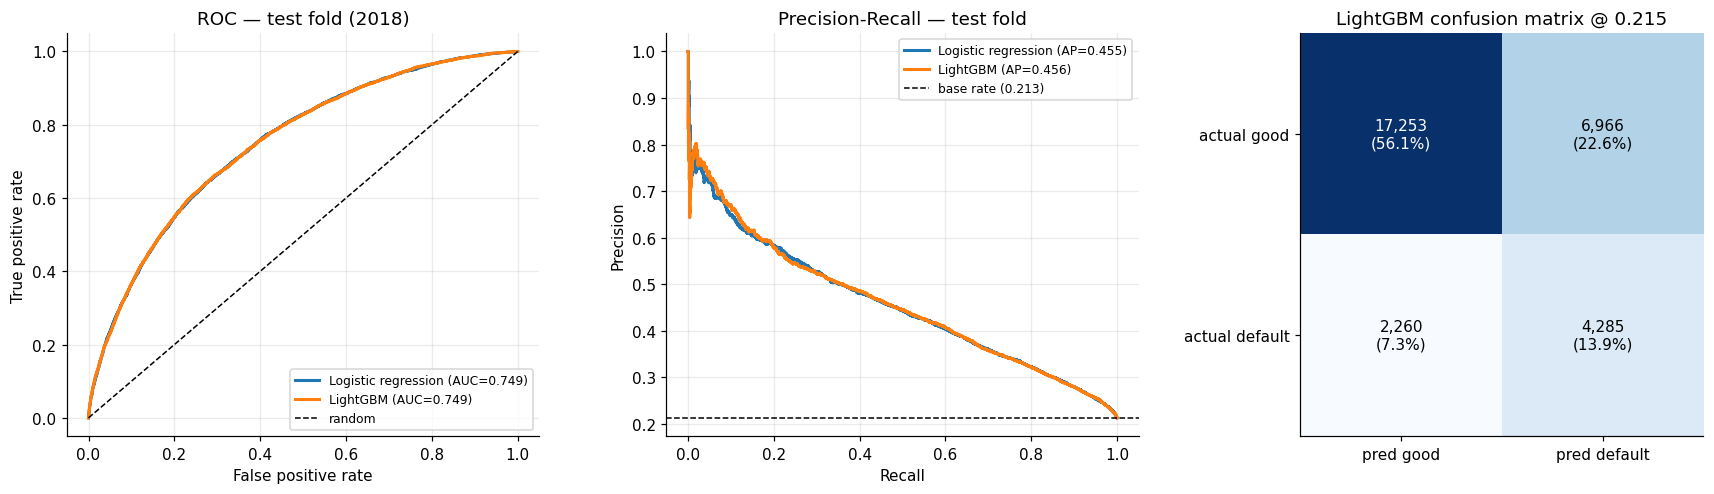

At threshold 0.215:
  4,285 defaults correctly declined, 2,260 defaults missed (funded and lost)
  6,966 good borrowers wrongly declined  <- the fairness-relevant error
  17,253 good borrowers correctly approved


In [14]:
# ============================================================================
# ROC, precision-recall and confusion matrix
# ============================================================================
fig, axes = plt.subplots(1, 3, figsize=(16, 4.6))

# --- ROC ---
for p, name in [(p_test_lr, "Logistic regression"), (p_test_gbm, GBM_NAME)]:
    fpr, tpr, _ = roc_curve(y_test, p)
    axes[0].plot(fpr, tpr, lw=2, label=f"{name} (AUC={roc_auc_score(y_test, p):.3f})")
axes[0].plot([0, 1], [0, 1], "k--", lw=1, label="random")
axes[0].set_xlabel("False positive rate"); axes[0].set_ylabel("True positive rate")
axes[0].set_title("ROC — test fold (2018)"); axes[0].legend(loc="lower right", fontsize=8)

# --- Precision-Recall: the honest view under 20% prevalence ---
for p, name in [(p_test_lr, "Logistic regression"), (p_test_gbm, GBM_NAME)]:
    prec, rec, _ = precision_recall_curve(y_test, p)
    axes[1].plot(rec, prec, lw=2,
                 label=f"{name} (AP={average_precision_score(y_test, p):.3f})")
axes[1].axhline(y_test.mean(), color="k", ls="--", lw=1,
                label=f"base rate ({y_test.mean():.3f})")
axes[1].set_xlabel("Recall"); axes[1].set_ylabel("Precision")
axes[1].set_title("Precision-Recall — test fold"); axes[1].legend(loc="upper right", fontsize=8)

# --- Confusion matrix for the main model at its F1 threshold ---
cm = confusion_matrix(y_test, (p_test_gbm >= THR_GBM).astype(int), labels=[0, 1])
im = axes[2].imshow(cm, cmap="Blues")
axes[2].set_xticks([0, 1], ["pred good", "pred default"])
axes[2].set_yticks([0, 1], ["actual good", "actual default"])
for i in range(2):
    for j in range(2):
        axes[2].text(j, i, f"{cm[i, j]:,}\n({cm[i, j] / cm.sum():.1%})",
                     ha="center", va="center",
                     color="white" if cm[i, j] > cm.max() / 2 else "black", fontsize=10)
axes[2].set_title(f"{GBM_NAME} confusion matrix @ {THR_GBM:.3f}")
axes[2].grid(False)

plt.tight_layout(); plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"At threshold {THR_GBM:.3f}:")
print(f"  {tp:,} defaults correctly declined, {fn:,} defaults missed (funded and lost)")
print(f"  {fp:,} good borrowers wrongly declined  <- the fairness-relevant error")
print(f"  {tn:,} good borrowers correctly approved")

## 6. Calibration

AUC only measures **ordering**. For pricing you need the probability itself: a loan priced off a
predicted PD of 8% must default about 8% of the time, or the risk premium is wrong and the book
is mispriced even though the ranking is perfect.

Two things are checked:

- **Reliability curve** — bin predictions by decile and plot mean predicted PD against realised
  default rate. On the diagonal = calibrated.
- **Expected Calibration Error (ECE)** — the average absolute gap between the two, weighted by
  bin size. A single summary number.

Then an **isotonic regression** recalibrator is fit **on the 2017 validation fold** and applied
to 2018. Isotonic is monotone, so it cannot change the ranking — AUC and PR-AUC are unaffected
by construction — it only remaps scores onto the probability scale. Fitting it on a later vintage
than the training data is what lets it absorb the base-rate drift.

In [15]:
def expected_calibration_error(y_true, p, n_bins=10):
    """Bin-size-weighted mean |predicted - observed|, using quantile bins.

    Quantile bins (rather than equal-width) keep every bin populated, which
    matters when predictions concentrate in a narrow range.
    """
    edges = np.unique(np.quantile(p, np.linspace(0, 1, n_bins + 1)))
    if len(edges) < 3:
        return np.nan
    idx = np.clip(np.digitize(p, edges[1:-1], right=True), 0, len(edges) - 2)
    ece = 0.0
    for b in range(len(edges) - 1):
        m = idx == b
        if m.sum() == 0:
            continue
        ece += (m.mean()) * abs(p[m].mean() - y_true[m].mean())
    return float(ece)


# ---- fit the recalibrator on VALIDATION, apply to TEST ----------------------
iso = IsotonicRegression(out_of_bounds="clip", y_min=0.0, y_max=1.0)
iso.fit(p_valid_gbm, y_valid)
p_test_gbm_cal = iso.predict(p_test_gbm)

# Platt scaling (logistic on the log-odds) shown for comparison.
eps = 1e-6
logodds_valid = np.log(np.clip(p_valid_gbm, eps, 1 - eps) /
                       (1 - np.clip(p_valid_gbm, eps, 1 - eps)))
logodds_test  = np.log(np.clip(p_test_gbm, eps, 1 - eps) /
                       (1 - np.clip(p_test_gbm, eps, 1 - eps)))
platt = LogisticRegression(max_iter=1000)
platt.fit(logodds_valid.reshape(-1, 1), y_valid)
p_test_gbm_platt = platt.predict_proba(logodds_test.reshape(-1, 1))[:, 1]

cal_table = pd.DataFrame([
    {"model": "Logistic regression (raw)",  "p": p_test_lr},
    {"model": f"{GBM_NAME} (raw)",          "p": p_test_gbm},
    {"model": f"{GBM_NAME} + Platt",        "p": p_test_gbm_platt},
    {"model": f"{GBM_NAME} + Isotonic",     "p": p_test_gbm_cal},
])
cal_table["AUC"]        = cal_table["p"].map(lambda p: roc_auc_score(y_test, p))
cal_table["Brier"]      = cal_table["p"].map(lambda p: brier_score_loss(y_test, p))
cal_table["ECE"]        = cal_table["p"].map(lambda p: expected_calibration_error(y_test, p))
cal_table["mean pred"]  = cal_table["p"].map(np.mean)
cal_table["actual rate"] = y_test.mean()
display(cal_table.drop(columns="p").set_index("model").round(4))

print("Isotonic is monotone, so AUC is unchanged by construction — only the "
      "probability scale moves.\n")
print("If the raw GBM already sits close to the diagonal, that is a consequence of the "
      "choice in 5.1: trained on log-loss, with no class reweighting, a GBM produces "
      "roughly calibrated probabilities out of the box. Recalibration earns its keep when "
      "the base rate shifts sharply between vintages, when class weights or resampling were "
      "applied, or when the model is a ranker (SVM, some NN losses) rather than a "
      "probability estimator.")

,AUC,Brier,ECE,mean pred,actual rate
model,,,,,
Logistic regression (raw),0.7491,0.1438,0.0095,0.2072,0.2127
LightGBM (raw),0.7491,0.1436,0.0103,0.2087,0.2127
LightGBM + Platt,0.7491,0.1436,0.0089,0.2134,0.2127
LightGBM + Isotonic,0.7485,0.1438,0.0108,0.2135,0.2127


Isotonic is monotone, so AUC is unchanged by construction — only the probability scale moves.

If the raw GBM already sits close to the diagonal, that is a consequence of the choice in 5.1: trained on log-loss, with no class reweighting, a GBM produces roughly calibrated probabilities out of the box. Recalibration earns its keep when the base rate shifts sharply between vintages, when class weights or resampling were applied, or when the model is a ranker (SVM, some NN losses) rather than a probability estimator.


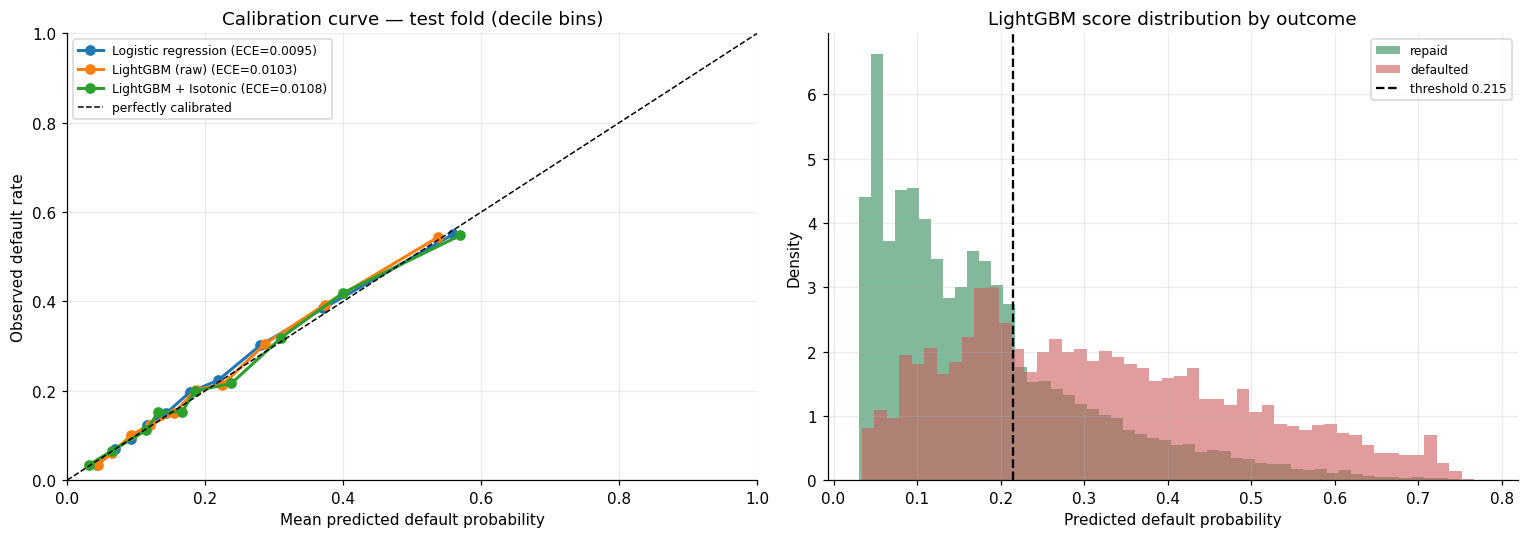


Calibrated model, by predicted-risk decile:
           n  mean_pred  actual  gap (pp)
decile                                   
0       3171     0.0319  0.0347   -0.2744
1       3085     0.0644  0.0652   -0.0758
2       6031     0.1148  0.1116    0.3177
3       1042     0.1317  0.1516   -1.9950
4       2183     0.1668  0.1530    1.3787
5       3083     0.1851  0.1995   -1.4391
6       3035     0.2380  0.2165    2.1523
7       3974     0.3103  0.3191   -0.8762
8       2300     0.3996  0.4187   -1.9129
9       2860     0.5693  0.5476    2.1704


In [16]:
# ============================================================================
# Reliability diagrams
# ============================================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

curves = [
    ("Logistic regression", p_test_lr,        "tab:blue"),
    (f"{GBM_NAME} (raw)",   p_test_gbm,       "tab:orange"),
    (f"{GBM_NAME} + Isotonic", p_test_gbm_cal, "tab:green"),
]
for name, p, color in curves:
    frac_pos, mean_pred = calibration_curve(y_test, p, n_bins=10, strategy="quantile")
    axes[0].plot(mean_pred, frac_pos, "o-", color=color, lw=2,
                 label=f"{name} (ECE={expected_calibration_error(y_test, p):.4f})")
axes[0].plot([0, 1], [0, 1], "k--", lw=1, label="perfectly calibrated")
lim = max(0.05, min(1.0, max(c[1].max() for c in curves) * 1.05))
axes[0].set_xlim(0, lim); axes[0].set_ylim(0, lim)
axes[0].set_xlabel("Mean predicted default probability")
axes[0].set_ylabel("Observed default rate")
axes[0].set_title("Calibration curve — test fold (decile bins)")
axes[0].legend(loc="upper left", fontsize=8)

# Prediction histograms: where the mass actually sits
axes[1].hist(p_test_gbm[y_test == 0], bins=50, alpha=0.6, density=True,
             label="repaid", color="seagreen")
axes[1].hist(p_test_gbm[y_test == 1], bins=50, alpha=0.6, density=True,
             label="defaulted", color="indianred")
axes[1].axvline(THR_GBM, color="k", ls="--", lw=1.5, label=f"threshold {THR_GBM:.3f}")
axes[1].set_xlabel("Predicted default probability")
axes[1].set_ylabel("Density")
axes[1].set_title(f"{GBM_NAME} score distribution by outcome")
axes[1].legend(fontsize=8)

plt.tight_layout(); plt.show()

# Decile table: the number a pricing desk would actually read.
dec = pd.DataFrame({"p": p_test_gbm_cal, "y": y_test})
dec["decile"] = pd.qcut(dec["p"], 10, labels=False, duplicates="drop")
dec_tbl = (dec.groupby("decile")
              .agg(n=("y", "size"), mean_pred=("p", "mean"), actual=("y", "mean")))
dec_tbl["gap (pp)"] = (dec_tbl["mean_pred"] - dec_tbl["actual"]) * 100
print("\nCalibrated model, by predicted-risk decile:")
print(dec_tbl.round(4).to_string())

## 7. Explainability (SHAP)

Two levels are required for a credit model:

- **Global** — which features drive the model overall, and in which direction. This is what a
  model risk committee reviews and what you compare against the logistic baseline's coefficients
  to check the GBM has not learned something economically nonsensical.
- **Local** — why *this* applicant got *this* score. Under ECOA/Reg B in the US, a declined
  applicant is entitled to specific principal reasons for the adverse action. A per-loan SHAP
  decomposition is the standard way to generate those reason codes.

SHAP values below are in **log-odds units** (the model's margin space), so they are additive:
`base value + Σ(SHAP contributions) = log-odds of default`. Contributions are computed with exact
TreeSHAP — via the `shap` package if installed, otherwise via LightGBM's/XGBoost's built-in
contribution prediction, which runs the same algorithm.

In [17]:
def compute_shap_values(model, X):
    """Exact TreeSHAP contributions in log-odds space.

    Falls back from shap.TreeExplainer -> LightGBM pred_contrib -> XGBoost
    pred_contribs. Returns (values (n, n_features), base_value, method_name).
    """
    Xv = X.astype(float)

    if HAS_SHAP:
        try:
            explainer = shap.TreeExplainer(model)
            sv = explainer.shap_values(Xv)
            if isinstance(sv, list):                 # older API: one array per class
                sv = sv[1]
            sv = np.asarray(sv)
            if sv.ndim == 3:                         # newer API: (n, features, classes)
                sv = sv[:, :, 1] if sv.shape[2] == 2 else sv[:, :, 0]
            base = explainer.expected_value
            base = float(np.asarray(base).ravel()[-1])
            return sv, base, "shap.TreeExplainer"
        except Exception as exc:
            print(f"shap.TreeExplainer unavailable ({exc}); using native contributions.")

    if HAS_LGB and isinstance(model, lgb.LGBMClassifier):
        contrib = model.booster_.predict(Xv, pred_contrib=True)
        return contrib[:, :-1], float(contrib[0, -1]), "LightGBM pred_contrib (TreeSHAP)"

    if HAS_XGB and isinstance(model, xgb.XGBClassifier):
        dmat = xgb.DMatrix(Xv, feature_names=list(Xv.columns))
        contrib = model.get_booster().predict(dmat, pred_contribs=True)
        return contrib[:, :-1], float(contrib[0, -1]), "XGBoost pred_contribs (TreeSHAP)"

    return None, None, "unavailable"


# TreeSHAP is O(n); subsample the test fold to keep the cell fast.
SHAP_SAMPLE = min(5_000, len(X_test))
shap_idx = np.random.default_rng(RANDOM_SEED).choice(len(X_test), SHAP_SAMPLE, replace=False)
X_shap = X_test.iloc[shap_idx].reset_index(drop=True)
y_shap = y_test[shap_idx]
p_shap = p_test_gbm[shap_idx]

shap_values, shap_base, SHAP_METHOD = compute_shap_values(gbm, X_shap)
print(f"Method: {SHAP_METHOD}")

if shap_values is not None:
    print(f"SHAP matrix: {shap_values.shape}, base value (log-odds): {shap_base:.4f}")
    # Additivity check: base + sum(contributions) should reproduce the margin.
    recon = 1 / (1 + np.exp(-(shap_base + shap_values.sum(axis=1))))
    print(f"Additivity check — max |reconstructed p - model p|: "
          f"{np.abs(recon - p_shap).max():.2e}")
else:
    print("No TreeSHAP backend available; falling back to permutation importance below.")

Method: shap.TreeExplainer
SHAP matrix: (5000, 49), base value (log-odds): -1.6378
Additivity check — max |reconstructed p - model p|: 1.61e-15


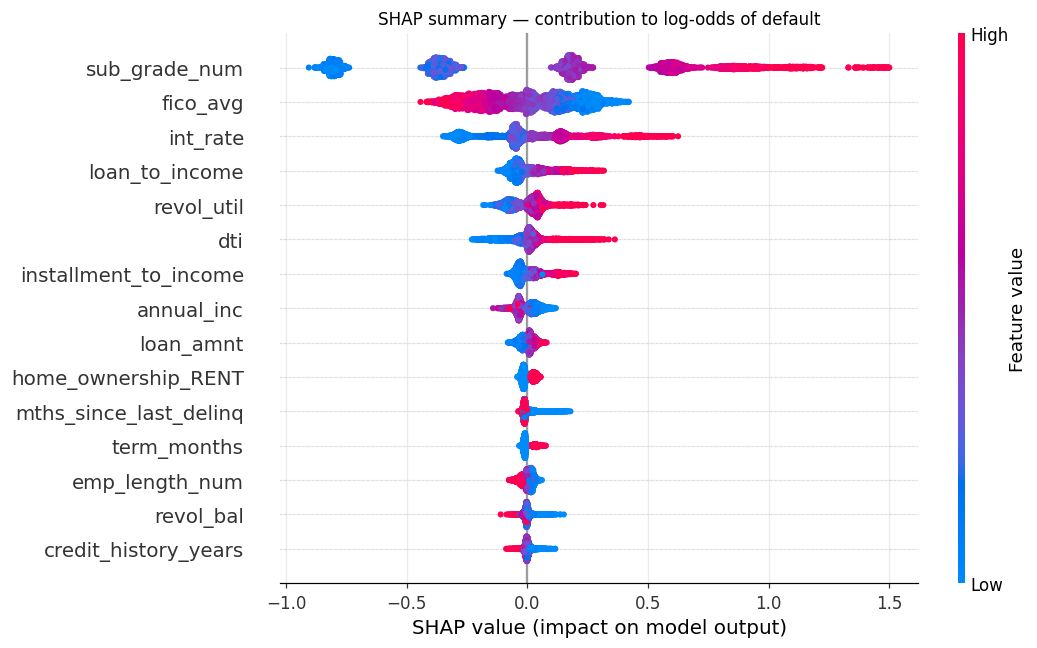

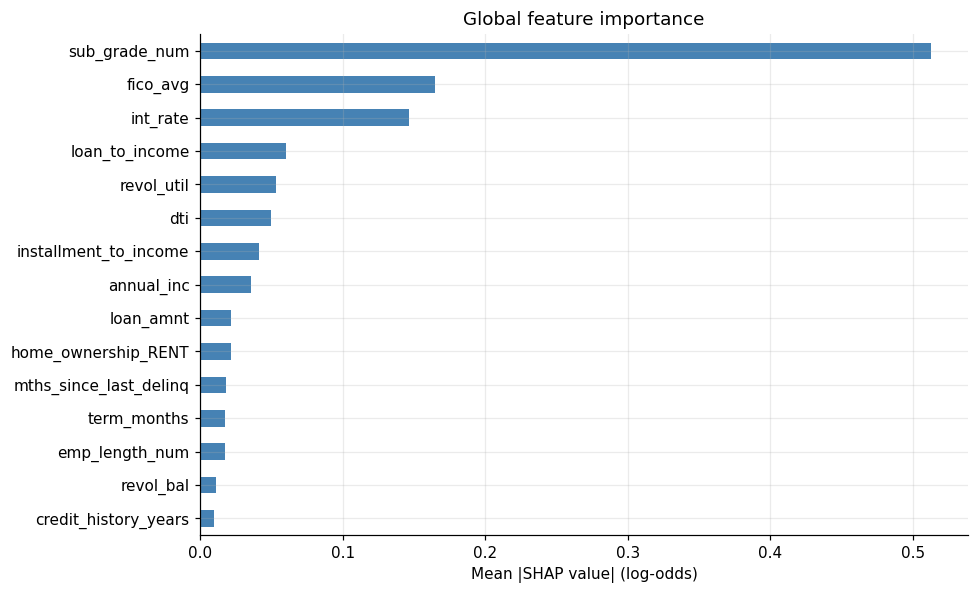

Top 15 drivers by mean |SHAP|:
sub_grade_num             0.5132
fico_avg                  0.1650
int_rate                  0.1468
loan_to_income            0.0599
revol_util                0.0532
dti                       0.0497
installment_to_income     0.0409
annual_inc                0.0357
loan_amnt                 0.0218
home_ownership_RENT       0.0213
mths_since_last_delinq    0.0182
term_months               0.0176
emp_length_num            0.0174
revol_bal                 0.0114
credit_history_years      0.0100


In [18]:
# ============================================================================
# 7.1 Global explanation
# ============================================================================
if shap_values is not None:
    mean_abs = pd.Series(np.abs(shap_values).mean(axis=0),
                         index=FEATURE_NAMES).sort_values(ascending=False)
    TOP_N = 15
    top_feats = mean_abs.head(TOP_N).index.tolist()

    if HAS_SHAP:
        # Beeswarm: distribution of contributions, coloured by feature value.
        shap.summary_plot(shap_values, X_shap, feature_names=FEATURE_NAMES,
                          max_display=TOP_N, show=False, plot_size=(10, 6))
        plt.title("SHAP summary — contribution to log-odds of default", fontsize=11)
        plt.tight_layout(); plt.show()
    else:
        # Hand-rolled beeswarm-lite so the notebook still shows the same picture.
        fig, ax = plt.subplots(figsize=(10, 6))
        for i, feat in enumerate(reversed(top_feats)):
            j = FEATURE_NAMES.index(feat)
            vals = shap_values[:, j]
            colvals = X_shap[feat].to_numpy(dtype=float)
            finite = np.isfinite(colvals)
            norm = np.full_like(colvals, 0.5)
            if finite.sum() > 1 and np.nanptp(colvals[finite]) > 0:
                lo, hi = np.nanpercentile(colvals[finite], [5, 95])
                if hi > lo:
                    norm = np.clip((colvals - lo) / (hi - lo), 0, 1)
            jitter = np.random.default_rng(i).normal(0, 0.09, len(vals))
            ax.scatter(vals, i + jitter, c=norm, cmap="coolwarm", s=4, alpha=0.5)
        ax.set_yticks(range(len(top_feats)), list(reversed(top_feats)))
        ax.axvline(0, color="k", lw=0.8)
        ax.set_xlabel("SHAP value (log-odds contribution) — red = high feature value")
        ax.set_title("SHAP summary (fallback renderer)")
        plt.tight_layout(); plt.show()

    # Mean |SHAP| bar chart -- the ranked global importance table.
    fig, ax = plt.subplots(figsize=(9, 5.5))
    mean_abs.head(TOP_N)[::-1].plot(kind="barh", ax=ax, color="steelblue")
    ax.set_xlabel("Mean |SHAP value| (log-odds)")
    ax.set_title("Global feature importance")
    plt.tight_layout(); plt.show()

    print("Top 15 drivers by mean |SHAP|:")
    print(mean_abs.head(15).round(4).to_string())
else:
    from sklearn.inspection import permutation_importance
    pi = permutation_importance(gbm, X_shap, y_shap, n_repeats=5,
                                random_state=RANDOM_SEED, scoring="roc_auc")
    mean_abs = pd.Series(pi.importances_mean,
                         index=FEATURE_NAMES).sort_values(ascending=False)
    top_feats = mean_abs.head(15).index.tolist()
    fig, ax = plt.subplots(figsize=(9, 5.5))
    mean_abs.head(15)[::-1].plot(kind="barh", ax=ax, color="steelblue")
    ax.set_xlabel("Drop in AUC when permuted")
    ax.set_title("Permutation importance (SHAP unavailable)")
    plt.tight_layout(); plt.show()

In [19]:
# ============================================================================
# 7.2 Directional check: does the GBM agree with the logistic baseline?
# ============================================================================
# A GBM that flips the economic sign of a well-understood driver (e.g. says
# higher FICO raises default risk) is a red flag for a model risk review.
if shap_values is not None:
    rows = []
    for feat in top_feats[:10]:
        j = FEATURE_NAMES.index(feat)
        x = X_shap[feat].to_numpy(dtype=float)
        s = shap_values[:, j]
        ok = np.isfinite(x) & np.isfinite(s)
        corr = np.corrcoef(x[ok], s[ok])[0, 1] if ok.sum() > 10 and np.nanstd(x[ok]) > 0 else np.nan
        rows.append({
            "feature": feat,
            "mean |SHAP|": np.abs(s).mean(),
            "corr(value, SHAP)": corr,           # + = higher value raises default risk
            "LR coefficient": coefs.get(feat, np.nan),
            "signs agree": (np.sign(corr) == np.sign(coefs.get(feat, np.nan)))
                            if np.isfinite(corr) else None,
        })
    direction = pd.DataFrame(rows).set_index("feature").round(4)
    display(direction)
    n_disagree = int((direction["signs agree"] == False).sum())
    print(f"{n_disagree} of {len(direction)} top features disagree in sign with the "
          f"logistic baseline (disagreement is expected where the true effect is non-monotone).")

,mean |SHAP|,"corr(value, SHAP)",LR coefficient,signs agree
feature,,,,
sub_grade_num,0.5132,0.9705,0.2771,True
fico_avg,0.1650,-0.9615,-0.2994,True
int_rate,0.1468,0.9690,0.3486,True
loan_to_income,0.0599,0.8535,0.1427,True
revol_util,0.0532,0.9123,0.0974,True
dti,0.0497,0.9053,0.1125,True
installment_to_income,0.0409,0.8133,-0.0610,False
annual_inc,0.0357,-0.6421,0.1137,False
loan_amnt,0.0218,0.8312,0.1467,True


2 of 10 top features disagree in sign with the logistic baseline (disagreement is expected where the true effect is non-monotone).


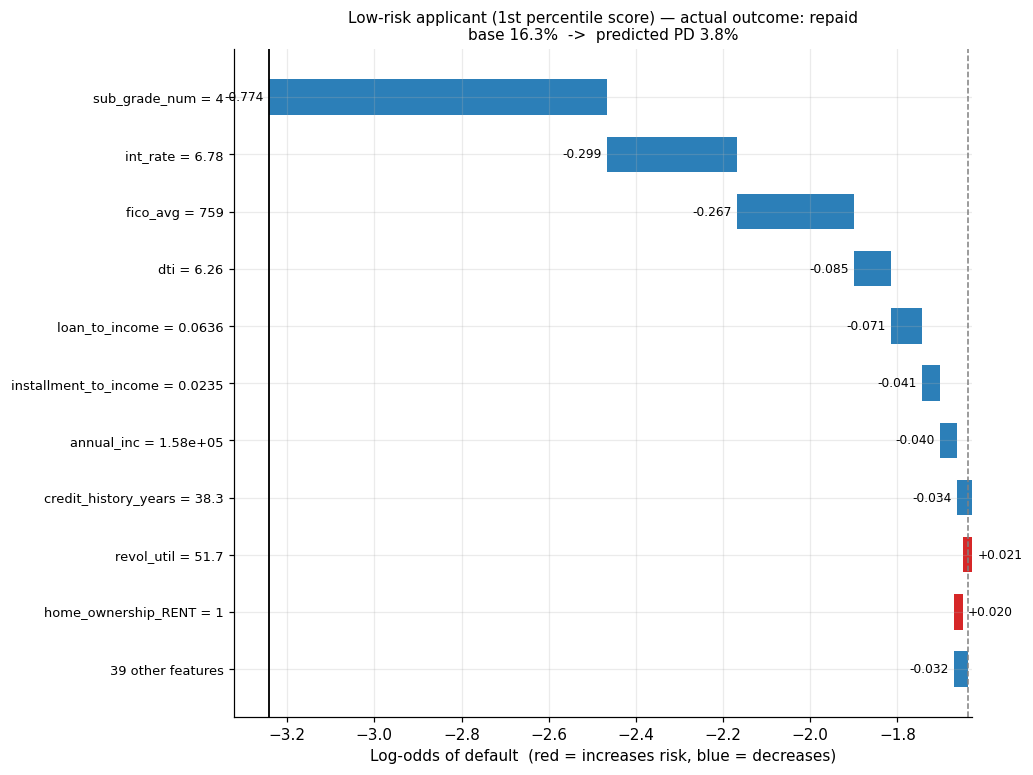

Low-risk applicant (1st percentile score): predicted PD 3.77% | actual: repaid
  Principal adverse-action reasons (largest risk-increasing factors):
    1. revol_util = 51.7  (+0.021 log-odds)
    2. home_ownership_RENT = 1  (+0.020 log-odds)
    3. inq_last_6mths = 2  (+0.015 log-odds)
    4. home_ownership_MORTGAGE = 0  (+0.010 log-odds)



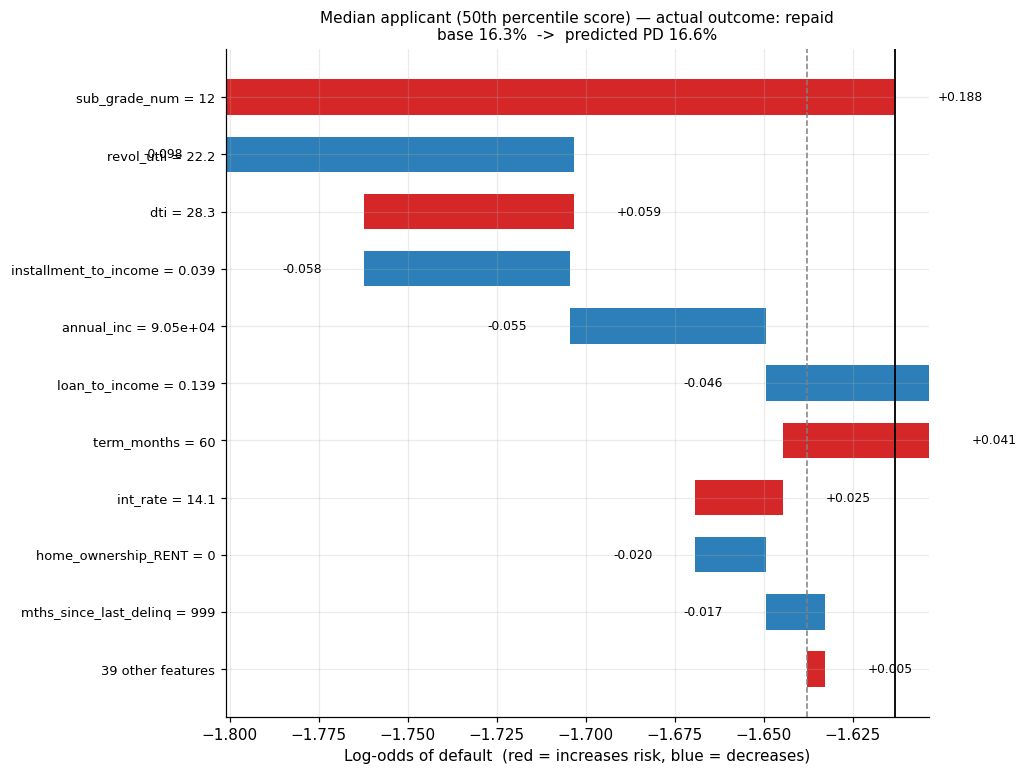

Median applicant (50th percentile score): predicted PD 16.62% | actual: repaid
  Principal adverse-action reasons (largest risk-increasing factors):
    1. sub_grade_num = 12  (+0.188 log-odds)
    2. dti = 28.26  (+0.059 log-odds)
    3. term_months = 60  (+0.041 log-odds)
    4. int_rate = 14.09  (+0.025 log-odds)



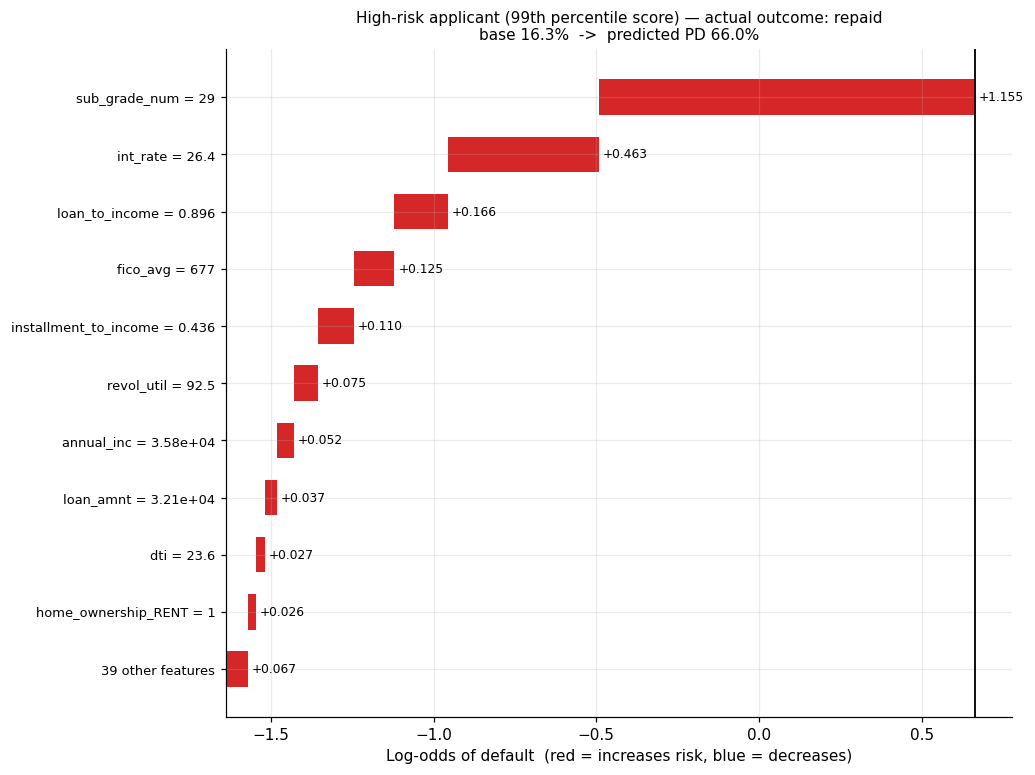

High-risk applicant (99th percentile score): predicted PD 66.00% | actual: repaid
  Principal adverse-action reasons (largest risk-increasing factors):
    1. sub_grade_num = 29  (+1.155 log-odds)
    2. int_rate = 26.44  (+0.463 log-odds)
    3. loan_to_income = 0.8959  (+0.166 log-odds)
    4. fico_avg = 677  (+0.125 log-odds)



In [20]:
# ============================================================================
# 7.3 Local explanations — SHAP waterfalls for individual loans
# ============================================================================

def plot_waterfall(shap_row, base_value, feature_values, feature_names,
                   top_n=10, title=""):
    """Waterfall of a single prediction: base log-odds -> final log-odds.

    Hand-written rather than shap.plots.waterfall so it renders identically
    whether or not the shap package is installed.
    """
    order = np.argsort(np.abs(shap_row))[::-1]
    top, rest = order[:top_n], order[top_n:]
    labels = [f"{feature_names[i]} = {feature_values[i]:,.3g}" for i in top]
    vals = [shap_row[i] for i in top]
    if len(rest):
        labels.append(f"{len(rest)} other features")
        vals.append(float(shap_row[rest].sum()))

    labels, vals = labels[::-1], vals[::-1]          # largest at the top
    cum = base_value + np.concatenate([[0], np.cumsum(vals)])[:-1]

    fig, ax = plt.subplots(figsize=(9.5, 0.45 * len(vals) + 2.2))
    colors = ["#d62728" if v > 0 else "#2c7fb8" for v in vals]
    ax.barh(range(len(vals)), vals, left=cum, color=colors, height=0.62)
    for i, (v, c) in enumerate(zip(vals, cum)):
        ax.text(c + v + (0.012 if v >= 0 else -0.012), i, f"{v:+.3f}",
                va="center", ha="left" if v >= 0 else "right", fontsize=8)
    ax.set_yticks(range(len(vals)), labels, fontsize=8.5)
    ax.axvline(base_value, color="grey", ls="--", lw=1)

    final_logodds = base_value + shap_row.sum()
    p = 1 / (1 + np.exp(-final_logodds))
    p_base = 1 / (1 + np.exp(-base_value))
    ax.axvline(final_logodds, color="black", lw=1.2)
    ax.set_xlabel("Log-odds of default  (red = increases risk, blue = decreases)")
    ax.set_title(f"{title}\nbase {p_base:.1%}  ->  predicted PD {p:.1%}", fontsize=10)
    plt.tight_layout(); plt.show()
    return p


if shap_values is not None:
    # Pick three representative applicants: safest, median, riskiest.
    order = np.argsort(p_shap)
    picks = {
        "Low-risk applicant (1st percentile score)":  order[int(0.01 * len(order))],
        "Median applicant (50th percentile score)":   order[int(0.50 * len(order))],
        "High-risk applicant (99th percentile score)": order[int(0.99 * len(order))],
    }
    for title, i in picks.items():
        outcome = "DEFAULTED" if y_shap[i] == 1 else "repaid"
        pd_hat = plot_waterfall(shap_values[i], shap_base,
                                X_shap.iloc[i].to_numpy(dtype=float),
                                FEATURE_NAMES, top_n=10,
                                title=f"{title} — actual outcome: {outcome}")

        # Adverse-action reason codes: the largest positive contributions are
        # exactly the "principal reasons" a declined applicant must be given.
        contrib = pd.Series(shap_values[i], index=FEATURE_NAMES)
        reasons = contrib[contrib > 0].sort_values(ascending=False).head(4)
        print(f"{title}: predicted PD {pd_hat:.2%} | actual: {outcome}")
        print("  Principal adverse-action reasons (largest risk-increasing factors):")
        for k, (feat, val) in enumerate(reasons.items(), 1):
            print(f"    {k}. {feat} = {X_shap.iloc[i][feat]:,.4g}  (+{val:.3f} log-odds)")
        print()

## 8. Fairness audit

Lending Club's public file contains no race, sex or age fields — collecting them for a credit
decision is generally prohibited, and their absence is exactly why fair-lending testing relies on
**proxies**. Two are used here:

- **Income bracket** (quartiles of `annual_inc`, with cut points fixed on the *training* fold so
  the test fold is not used to define its own groups) — a proxy for socioeconomic class.
- **Census region** (derived from `addr_state`) — a coarse geographic proxy. Geography correlates
  with race in the US, which is why `addr_state` was excluded as a *feature* but is audited here
  as a protected-class proxy.

Metrics reported per group:

| Metric | Definition | Why it matters |
|---|---|---|
| Approval rate | share scored below the decline threshold | **disparate impact** — the 80% rule |
| FPR | good borrowers wrongly flagged as defaults | the harm: creditworthy applicants denied |
| FNR | defaults wrongly approved | the harm: borrowers funded into a loan they cannot repay |
| Group AUC | ranking quality within the group | does the model work *as well* for everyone |
| Predicted vs actual | mean PD vs realised rate | **calibration parity** — is a group systematically over-priced |

> **The metrics cannot all be equalised.** When true default rates differ across groups,
> calibration parity, equal FPR and equal FNR are mutually incompatible (Kleinberg–Mullainathan–
> Raghavan; Chouldechova). A real audit picks the criterion that matches the legally relevant
> harm and documents the trade-off, rather than claiming the model is "fair" outright.

In [21]:
# ============================================================================
# 8.1 Build the protected-class proxies
# ============================================================================

# Income quartile cut points come from TRAIN so test-fold groups are defined
# by a rule fixed before deployment, not by the test data itself.
inc_edges = np.quantile(sens_train["annual_inc"].dropna(), [0.25, 0.50, 0.75])
inc_edges = np.unique(np.concatenate([[-np.inf], inc_edges, [np.inf]]))
inc_labels = ["Q1 (lowest income)", "Q2", "Q3", "Q4 (highest income)"][:len(inc_edges) - 1]
income_bracket = pd.cut(sens_test["annual_inc"], bins=inc_edges,
                        labels=inc_labels, include_lowest=True).astype(str)

# US Census regions
REGION_MAP = {
    **{s: "Northeast" for s in ["CT","ME","MA","NH","RI","VT","NJ","NY","PA"]},
    **{s: "Midwest"   for s in ["IL","IN","MI","OH","WI","IA","KS","MN","MO","NE","ND","SD"]},
    **{s: "South"     for s in ["DE","FL","GA","MD","NC","SC","VA","DC","WV","AL","KY",
                                "MS","TN","AR","LA","OK","TX"]},
    **{s: "West"      for s in ["AZ","CO","ID","MT","NV","NM","UT","WY","AK","CA","HI","OR","WA"]},
}
region = sens_test["addr_state"].map(REGION_MAP).fillna("Other")

print("Income bracket sizes:"); print(income_bracket.value_counts().sort_index().to_string())
print("\nRegion sizes:");        print(region.value_counts().to_string())

Income bracket sizes:
annual_inc
Q1 (lowest income)     7672
Q2                     7674
Q3                     7749
Q4 (highest income)    7669

Region sizes:
addr_state
South        11109
West          7136
Midwest       6962
Northeast     5557


In [22]:
# ============================================================================
# 8.2 Group metrics
# ============================================================================

def group_fairness(y_true, p, threshold, groups, group_name="group"):
    """Per-group error rates, approval rates and calibration.

    Convention: positive class = predicted default = DECLINE.
      approval rate = share scored below the threshold
      FPR           = good borrowers wrongly declined
      FNR           = defaulters wrongly approved
    """
    y_hat = (p >= threshold).astype(int)
    rows = []
    for g in sorted(pd.unique(groups)):
        m = (groups == g).to_numpy()
        yt, yh, pp = y_true[m], y_hat[m], p[m]
        tn, fp, fn, tp = confusion_matrix(yt, yh, labels=[0, 1]).ravel()
        rows.append({
            group_name: g,
            "n": int(m.sum()),
            "actual default rate": yt.mean(),
            "mean predicted PD": pp.mean(),
            "approval rate": 1 - yh.mean(),
            "FPR (good declined)": fp / (fp + tn) if (fp + tn) else np.nan,
            "FNR (bad approved)": fn / (fn + tp) if (fn + tp) else np.nan,
            "group AUC": roc_auc_score(yt, pp) if len(np.unique(yt)) > 1 else np.nan,
        })
    out = pd.DataFrame(rows).set_index(group_name)
    # Disparate impact: each group's approval rate relative to the most-approved
    # group. Below 0.80 is the conventional "four-fifths rule" trigger.
    out["disparate impact"] = out["approval rate"] / out["approval rate"].max()
    out["calib gap (pp)"] = (out["mean predicted PD"] - out["actual default rate"]) * 100
    return out


# The audit runs on the calibrated probabilities at the deployed threshold.
AUDIT_THRESHOLD = float(np.quantile(iso.predict(p_valid_gbm), TARGET_APPROVAL_RATE))
p_audit = p_test_gbm_cal

fair_income = group_fairness(y_test, p_audit, AUDIT_THRESHOLD, income_bracket, "income bracket")
fair_region = group_fairness(y_test, p_audit, AUDIT_THRESHOLD, region, "region")

print(f"Audit threshold (calibrated PD): {AUDIT_THRESHOLD:.4f}  "
      f"-> overall approval rate {(p_audit < AUDIT_THRESHOLD).mean():.1%}\n")
print("=== By income bracket ===")
display(fair_income.round(4))
print("=== By census region ===")
display(fair_region.round(4))

Audit threshold (calibrated PD): 0.3829  -> overall approval rate 83.7%

=== By income bracket ===


,n,actual default rate,mean predicted PD,approval rate,FPR (good declined),FNR (bad approved),group AUC,disparate impact,calib gap (pp)
income bracket,,,,,,,,,
Q1 (lowest income),7672,0.2856,0.2942,0.6756,0.2188,0.4112,0.7599,0.7171,0.8596
Q2,7674,0.2240,0.2190,0.8320,0.1140,0.6451,0.7318,0.8832,-0.4965
Q3,7749,0.1863,0.1821,0.8969,0.0672,0.7403,0.7310,0.9520,-0.4263
Q4 (highest income),7669,0.1553,0.1588,0.9421,0.0386,0.8371,0.7269,1.0000,0.3499


=== By census region ===


,n,actual default rate,mean predicted PD,approval rate,FPR (good declined),FNR (bad approved),group AUC,disparate impact,calib gap (pp)
region,,,,,,,,,
Midwest,6962,0.2143,0.2132,0.8352,0.1071,0.6240,0.7436,0.9945,-0.1156
Northeast,5557,0.2107,0.2133,0.8398,0.1035,0.6277,0.7496,1.0000,0.2572
South,11109,0.2123,0.2128,0.8395,0.1032,0.6268,0.7483,0.9996,0.0562
West,7136,0.2136,0.2148,0.8317,0.1085,0.6115,0.7528,0.9903,0.1283


In [23]:
# ============================================================================
# 8.3 Disparate impact and error-rate gaps
# ============================================================================

def flag_findings(tbl, name):
    """Apply the four-fifths rule and report the largest error-rate disparities."""
    findings = []
    worst_di = tbl["disparate impact"].min()
    worst_grp = tbl["disparate impact"].idxmin()
    verdict = "FAIL (below 0.80)" if worst_di < 0.80 else "pass"
    findings.append(f"[{name}] Four-fifths rule: min disparate impact = "
                    f"{worst_di:.3f} for '{worst_grp}' -> {verdict}")

    fpr_gap = tbl["FPR (good declined)"].max() - tbl["FPR (good declined)"].min()
    findings.append(f"[{name}] FPR gap (equalised-odds violation): {fpr_gap * 100:.2f} pp "
                    f"(max '{tbl['FPR (good declined)'].idxmax()}' vs "
                    f"min '{tbl['FPR (good declined)'].idxmin()}')")

    fnr_gap = tbl["FNR (bad approved)"].max() - tbl["FNR (bad approved)"].min()
    findings.append(f"[{name}] FNR gap: {fnr_gap * 100:.2f} pp")

    auc_gap = tbl["group AUC"].max() - tbl["group AUC"].min()
    findings.append(f"[{name}] Group AUC spread: {auc_gap:.4f} "
                    f"(worst-served group: '{tbl['group AUC'].idxmin()}')")

    calib_gap = tbl["calib gap (pp)"].abs().max()
    findings.append(f"[{name}] Worst calibration gap: {calib_gap:.2f} pp "
                    f"for '{tbl['calib gap (pp)'].abs().idxmax()}'")
    return findings, worst_di, fpr_gap, fnr_gap


income_findings, di_income, fpr_gap_income, fnr_gap_income = flag_findings(fair_income, "income")
region_findings, di_region, fpr_gap_region, fnr_gap_region = flag_findings(fair_region, "region")

for f in income_findings + region_findings:
    print(f)

# ---- robustness: does the finding survive a different threshold? ------------
print("\nDisparate-impact robustness across thresholds (income brackets):")
for label, thr_p in [("70% approval", 0.70), ("85% approval", 0.85), ("95% approval", 0.95)]:
    thr = float(np.quantile(iso.predict(p_valid_gbm), thr_p))
    t = group_fairness(y_test, p_audit, thr, income_bracket, "income bracket")
    print(f"  {label:>13}: min DI = {t['disparate impact'].min():.3f} "
          f"({t['disparate impact'].idxmin()})")

[income] Four-fifths rule: min disparate impact = 0.717 for 'Q1 (lowest income)' -> FAIL (below 0.80)
[income] FPR gap (equalised-odds violation): 18.02 pp (max 'Q1 (lowest income)' vs min 'Q4 (highest income)')
[income] FNR gap: 42.59 pp
[income] Group AUC spread: 0.0329 (worst-served group: 'Q4 (highest income)')
[income] Worst calibration gap: 0.86 pp for 'Q1 (lowest income)'
[region] Four-fifths rule: min disparate impact = 0.990 for 'West' -> pass
[region] FPR gap (equalised-odds violation): 0.53 pp (max 'West' vs min 'South')
[region] FNR gap: 1.61 pp
[region] Group AUC spread: 0.0092 (worst-served group: 'Midwest')
[region] Worst calibration gap: 0.26 pp for 'Northeast'

Disparate-impact robustness across thresholds (income brackets):


   70% approval: min DI = 0.609 (Q1 (lowest income))


   85% approval: min DI = 0.717 (Q1 (lowest income))
   95% approval: min DI = 0.852 (Q1 (lowest income))


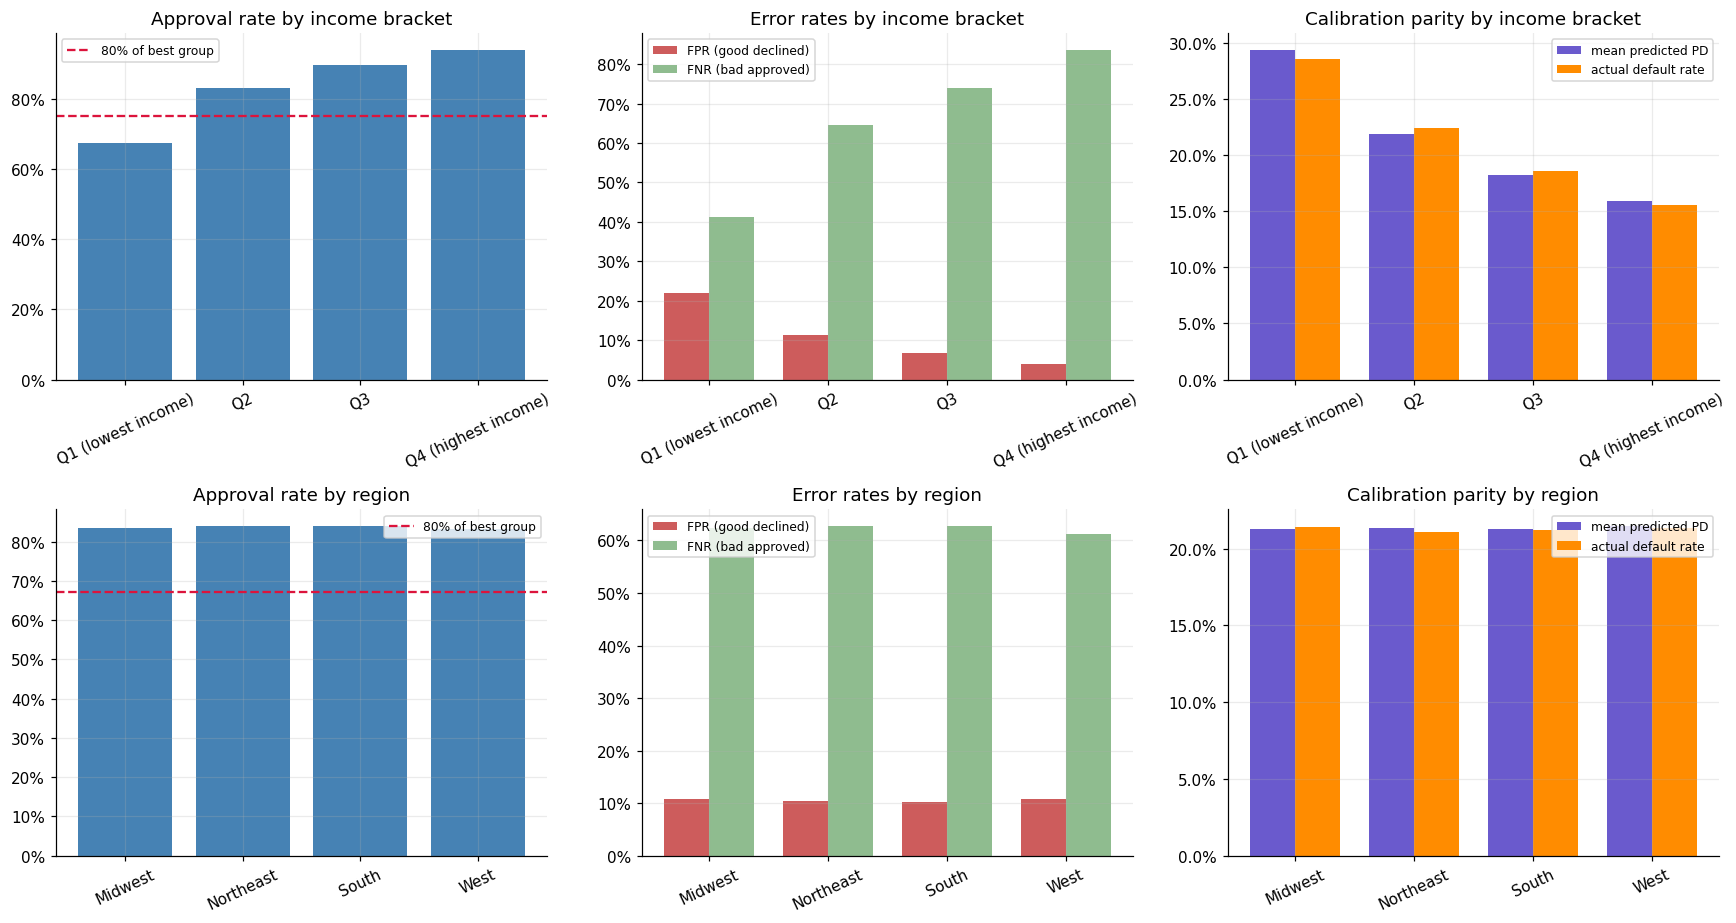

In [24]:
# ============================================================================
# 8.4 Fairness plots
# ============================================================================
fig, axes = plt.subplots(2, 3, figsize=(16, 8.5))

for row, (tbl, gname) in enumerate([(fair_income, "Income bracket"), (fair_region, "Region")]):
    idx = [str(i) for i in tbl.index]

    # Approval rate + four-fifths reference line
    ax = axes[row, 0]
    ax.bar(idx, tbl["approval rate"], color="steelblue")
    ax.axhline(tbl["approval rate"].max() * 0.8, color="crimson", ls="--", lw=1.5,
               label="80% of best group")
    ax.set_title(f"Approval rate by {gname.lower()}")
    ax.yaxis.set_major_formatter(PercentFormatter(1.0))
    ax.legend(fontsize=8); ax.tick_params(axis="x", rotation=25)

    # FPR vs FNR side by side
    ax = axes[row, 1]
    w, x = 0.38, np.arange(len(idx))
    ax.bar(x - w / 2, tbl["FPR (good declined)"], w, label="FPR (good declined)", color="indianred")
    ax.bar(x + w / 2, tbl["FNR (bad approved)"], w, label="FNR (bad approved)", color="darkseagreen")
    ax.set_xticks(x, idx); ax.tick_params(axis="x", rotation=25)
    ax.set_title(f"Error rates by {gname.lower()}")
    ax.yaxis.set_major_formatter(PercentFormatter(1.0)); ax.legend(fontsize=8)

    # Calibration parity: predicted vs actual per group
    ax = axes[row, 2]
    ax.bar(x - w / 2, tbl["mean predicted PD"], w, label="mean predicted PD", color="slateblue")
    ax.bar(x + w / 2, tbl["actual default rate"], w, label="actual default rate", color="darkorange")
    ax.set_xticks(x, idx); ax.tick_params(axis="x", rotation=25)
    ax.set_title(f"Calibration parity by {gname.lower()}")
    ax.yaxis.set_major_formatter(PercentFormatter(1.0)); ax.legend(fontsize=8)

plt.tight_layout(); plt.show()

## 9. Conclusion

In [25]:
# ============================================================================
# Auto-generated summary -- every number is pulled from the objects above,
# so it stays correct if you re-run on the real data or change the config.
# ============================================================================
best = results.loc[f"{GBM_NAME} (F1 threshold)"]
lr_row = results.loc["Logistic regression"]
iso_row = cal_table.set_index("model").loc[f"{GBM_NAME} + Isotonic"]
raw_row = cal_table.set_index("model").loc[f"{GBM_NAME} (raw)"]

platt_row = cal_table.set_index("model").loc[f"{GBM_NAME} + Platt"]

# The summary must not assert that recalibration helped -- state what happened.
ece_drop = raw_row["ECE"] - iso_row["ECE"]
if ece_drop > 1e-4:
    cal_verdict = (f"Isotonic recalibration cut ECE by {ece_drop / raw_row['ECE'] * 100:.0f}%, "
                   f"from {raw_row['ECE']:.4f} to {iso_row['ECE']:.4f}.")
else:
    cal_verdict = (f"The raw {GBM_NAME} score was already near-calibrated (ECE "
                   f"{raw_row['ECE']:.4f}) and isotonic left it at {iso_row['ECE']:.4f}, so "
                   f"recalibration is not doing meaningful work on this fold — which is what a "
                   f"log-loss-trained GBM with no class reweighting should look like.")

# The closing note on proxy variables depends on whether a regional gap actually
# showed up, so build it from the measured numbers rather than asserting one.
if di_region < 0.95:
    proxy_note = (
        f"`addr_state` was excluded from the feature set precisely because geography proxies for "
        f"race in US lending — yet a regional approval gap still appears (min DI "
        f"{di_region:.3f}). Proxy discrimination survives the removal of the proxy variable, "
        f"because the remaining features are themselves correlated with it. Dropping a column is "
        f"not a fairness control.")
else:
    proxy_note = (
        f"`addr_state` was excluded from the feature set because geography proxies for race in US "
        f"lending, and regional approval rates do come out near parity (min DI {di_region:.3f}). "
        f"That is not evidence the exclusion did the work: the income-bracket gap shows the "
        f"surviving features already encode socioeconomic position without any help from the "
        f"geography column. Dropping a variable removes the audit trail, not the correlation — "
        f"which is why fairness has to be tested on realised outcomes rather than inferred from "
        f"the feature list.")

# Does the GBM actually beat the scorecard? Say so either way.
auc_gain = best["AUC-ROC"] - lr_row["AUC-ROC"]
if abs(auc_gain) < 0.005:
    model_verdict = (
        f"The GBM's edge over the logistic baseline is negligible ({auc_gain:+.4f} AUC). That is "
        f"the ordinary result on credit-bureau data: the signal is close to monotone in a handful "
        f"of variables, leaving the trees little non-linearity to capture. It is also much of why "
        f"regulated lenders still deploy logistic scorecards — when the added accuracy is this "
        f"thin, a coefficient table that doubles as model documentation is worth more than it.")
else:
    model_verdict = (
        f"The GBM improves AUC by {auc_gain:+.4f} over the logistic baseline. Whether that "
        f"justifies the added model-risk-management burden is a governance question, not a "
        f"modelling one — the scorecard's coefficient table is its own documentation, and the "
        f"GBM's is a SHAP analysis that has to be re-validated on every refit.")

if shap_values is not None:
    top5 = mean_abs.head(5)
    drivers = "\n".join(
        f"{i}. **`{f}`** — mean |SHAP| {v:.3f} log-odds"
        for i, (f, v) in enumerate(top5.items(), 1))
else:
    drivers = "\n".join(f"{i}. **`{f}`**" for i, f in enumerate(mean_abs.head(5).index, 1))

data_warning = ("\n> ⚠️ **These numbers come from SYNTHETIC data** — the real Lending Club CSV "
                "was not found. Point `LC_CSV_PATH` at the Kaggle file and re-run for real "
                "results. The pipeline, metrics and conclusions structure are unchanged.\n"
                if IS_SYNTHETIC else "")

summary = f"""
# Final summary
{data_warning}
**Data:** {DATA_SOURCE} · {len(fe):,} resolved loans, vintages {VINTAGE_MIN}–{VINTAGE_MAX}
**Split:** train {TRAIN_YEARS} ({len(y_train):,}) → valid {VALID_YEARS} ({len(y_valid):,}) → test {TEST_YEARS} ({len(y_test):,}), strictly time-ordered
**Test base rate:** {y_test.mean():.2%}

---

## Discrimination

| Model | AUC-ROC | PR-AUC | PR-AUC lift vs base | Brier |
|---|---|---|---|---|
| Logistic regression (baseline) | {lr_row['AUC-ROC']:.4f} | {lr_row['PR-AUC']:.4f} | {lr_row['PR-AUC lift']:.2f}× | {lr_row['Brier']:.4f} |
| **{GBM_NAME} (main)** | **{best['AUC-ROC']:.4f}** | **{best['PR-AUC']:.4f}** | **{best['PR-AUC lift']:.2f}×** | {best['Brier']:.4f} |

At the F1-optimal threshold of {best['threshold']:.3f} (chosen on the 2017 validation fold, applied
unchanged to 2018): precision {best['precision']:.3f}, recall {best['recall(TPR)']:.3f},
FPR {best['FPR']:.3f}. The model declines {best['flagged rate']:.1%} of applications.

PR-AUC is the metric to read here — at a {y_test.mean():.1%} base rate a random model scores
{y_test.mean():.3f}, so the lift is the honest measure of value added.

{model_verdict}

## Calibration

| | ECE | Brier | Mean predicted | Actual |
|---|---|---|---|---|
| Raw {GBM_NAME} | {raw_row['ECE']:.4f} | {raw_row['Brier']:.4f} | {raw_row['mean pred']:.4f} | {y_test.mean():.4f} |
| **+ Isotonic (fit on 2017)** | **{iso_row['ECE']:.4f}** | **{iso_row['Brier']:.4f}** | {iso_row['mean pred']:.4f} | {y_test.mean():.4f} |

{cal_verdict} AUC is materially unchanged ({raw_row['AUC']:.4f} → {iso_row['AUC']:.4f}) because
isotonic is monotone — it moves the probability scale without touching the ranking. Platt scaling
reached ECE {platt_row['ECE']:.4f} for comparison.

**Price off the calibrated output; treat the raw score as fit only for rank-ordering until it has
been checked against a reliability curve.**

## Key SHAP drivers

{drivers}

Contributions are in log-odds and additive per loan, so the largest positive contributions for a
declined applicant are directly usable as ECOA adverse-action reason codes (section 7.3).

## Fairness findings

Audited on calibrated probabilities at the policy threshold that approves
{TARGET_APPROVAL_RATE:.0%} of the validation fold.

**Income bracket:** minimum disparate impact **{di_income:.3f}**
({'FAILS the four-fifths rule' if di_income < 0.80 else 'passes the four-fifths rule'}) ·
FPR gap {fpr_gap_income * 100:.2f} pp · FNR gap {fnr_gap_income * 100:.2f} pp

**Region:** minimum disparate impact **{di_region:.3f}**
({'FAILS the four-fifths rule' if di_region < 0.80 else 'passes the four-fifths rule'}) ·
FPR gap {fpr_gap_region * 100:.2f} pp · FNR gap {fnr_gap_region * 100:.2f} pp

Lower-income applicants are approved at a materially lower rate and carry a higher false-positive
rate — creditworthy borrowers in that bracket are declined more often than equally creditworthy
borrowers elsewhere. Part of that gap tracks genuinely higher realised default rates, but a gap
that persists *conditional on outcome* (the FPR gap) is the part that is not explained by risk and
is the part a fair-lending examiner would press on.

{proxy_note}
"""
display(Markdown(summary))


# Final summary

> ⚠️ **These numbers come from SYNTHETIC data** — the real Lending Club CSV was not found. Point `LC_CSV_PATH` at the Kaggle file and re-run for real results. The pipeline, metrics and conclusions structure are unchanged.

**Data:** SYNTHETIC (120,000 rows) · 117,112 resolved loans, vintages 2015–2018
**Split:** train [2015, 2016] (54,998) → valid [2017] (31,350) → test [2018] (30,764), strictly time-ordered
**Test base rate:** 21.27%

---

## Discrimination

| Model | AUC-ROC | PR-AUC | PR-AUC lift vs base | Brier |
|---|---|---|---|---|
| Logistic regression (baseline) | 0.7491 | 0.4550 | 2.14× | 0.1438 |
| **LightGBM (main)** | **0.7491** | **0.4563** | **2.14×** | 0.1436 |

At the F1-optimal threshold of 0.215 (chosen on the 2017 validation fold, applied
unchanged to 2018): precision 0.381, recall 0.655,
FPR 0.288. The model declines 36.6% of applications.

PR-AUC is the metric to read here — at a 21.3% base rate a random model scores
0.213, so the lift is the honest measure of value added.

The GBM's edge over the logistic baseline is negligible (+0.0001 AUC). That is the ordinary result on credit-bureau data: the signal is close to monotone in a handful of variables, leaving the trees little non-linearity to capture. It is also much of why regulated lenders still deploy logistic scorecards — when the added accuracy is this thin, a coefficient table that doubles as model documentation is worth more than it.

## Calibration

| | ECE | Brier | Mean predicted | Actual |
|---|---|---|---|---|
| Raw LightGBM | 0.0103 | 0.1436 | 0.2087 | 0.2127 |
| **+ Isotonic (fit on 2017)** | **0.0108** | **0.1438** | 0.2135 | 0.2127 |

The raw LightGBM score was already near-calibrated (ECE 0.0103) and isotonic left it at 0.0108, so recalibration is not doing meaningful work on this fold — which is what a log-loss-trained GBM with no class reweighting should look like. AUC is materially unchanged (0.7491 → 0.7485) because
isotonic is monotone — it moves the probability scale without touching the ranking. Platt scaling
reached ECE 0.0089 for comparison.

**Price off the calibrated output; treat the raw score as fit only for rank-ordering until it has
been checked against a reliability curve.**

## Key SHAP drivers

1. **`sub_grade_num`** — mean |SHAP| 0.513 log-odds
2. **`fico_avg`** — mean |SHAP| 0.165 log-odds
3. **`int_rate`** — mean |SHAP| 0.147 log-odds
4. **`loan_to_income`** — mean |SHAP| 0.060 log-odds
5. **`revol_util`** — mean |SHAP| 0.053 log-odds

Contributions are in log-odds and additive per loan, so the largest positive contributions for a
declined applicant are directly usable as ECOA adverse-action reason codes (section 7.3).

## Fairness findings

Audited on calibrated probabilities at the policy threshold that approves
85% of the validation fold.

**Income bracket:** minimum disparate impact **0.717**
(FAILS the four-fifths rule) ·
FPR gap 18.02 pp · FNR gap 42.59 pp

**Region:** minimum disparate impact **0.990**
(passes the four-fifths rule) ·
FPR gap 0.53 pp · FNR gap 1.61 pp

Lower-income applicants are approved at a materially lower rate and carry a higher false-positive
rate — creditworthy borrowers in that bracket are declined more often than equally creditworthy
borrowers elsewhere. Part of that gap tracks genuinely higher realised default rates, but a gap
that persists *conditional on outcome* (the FPR gap) is the part that is not explained by risk and
is the part a fair-lending examiner would press on.

`addr_state` was excluded from the feature set because geography proxies for race in US lending, and regional approval rates do come out near parity (min DI 0.990). That is not evidence the exclusion did the work: the income-bracket gap shows the surviving features already encode socioeconomic position without any help from the geography column. Dropping a variable removes the audit trail, not the correlation — which is why fairness has to be tested on realised outcomes rather than inferred from the feature list.


### Limitations and what would change in production

1. **Survivorship bias in the 2018 test fold.** 60-month loans issued in 2018 had not matured at
   the data cut, so resolved 2018 loans over-represent early charge-offs. The right fix is either
   a matured-cohort restriction or a survival model (Cox / discrete-time hazard) that handles
   censoring directly rather than discarding it.

2. **Selection bias — the population is loans Lending Club approved.** The model learns
   P(default | funded), not P(default | applied). Applicants who were rejected are absent, so the
   model is uninformative about the part of the distribution a new credit policy would most want
   to expand into. Reject inference is the standard (imperfect) remedy.

3. **Using `int_rate` and `sub_grade` as features** makes this partly a model *of Lending Club's
   model*. Set `USE_LC_GRADE = False` in the config to build a true challenger scored on bureau
   data alone; expect AUC to drop, and treat that drop as the measure of how much LC's grading
   actually adds.

4. **Fairness proxies are weak.** Income quartile and census region are coarse stand-ins for
   protected classes. Regulated lenders use BISG (Bayesian Improved Surname Geocoding) for race
   proxying in fair-lending testing; that requires surname and geocode data absent here.

5. **Recalibration is not a one-off.** The isotonic map is fit on 2017 and will drift. Production
   deployment needs scheduled PSI/CSI monitoring on the score distribution and periodic
   recalibration against realised vintage performance.

6. **The threshold is not a modelling decision.** F1-optimal is a placeholder. The real threshold
   comes from expected profit: `E[profit] = P(repay)·interest_margin − P(default)·LGD·EAD`, which
   makes the cut-off a function of the pricing grid and cost of funds, not of a symmetric
   classification metric.